In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import torch.nn as nn
from tqdm import tqdm
import yfinance as yf
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, accuracy_score, f1_score, r2_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


# Leitura dos arquivos


In [2]:
DAILY_DIRECTORY = Path("daily")

shape: (6, 2)
┌───────────────────────┬────────┐
│ source                ┆ len    │
│ ---                   ┆ ---    │
│ str                   ┆ u32    │
╞═══════════════════════╪════════╡
│ yahoo.com             ┆ 582763 │
│ reuters.com           ┆ 475871 │
│ bloomberg.com         ┆ 87256  │
│ cnbc.com              ┆ 76054  │
│ thomsonreuters.com    ┆ 504    │
│ thomsonreuters.com.au ┆ 16     │
└───────────────────────┴────────┘


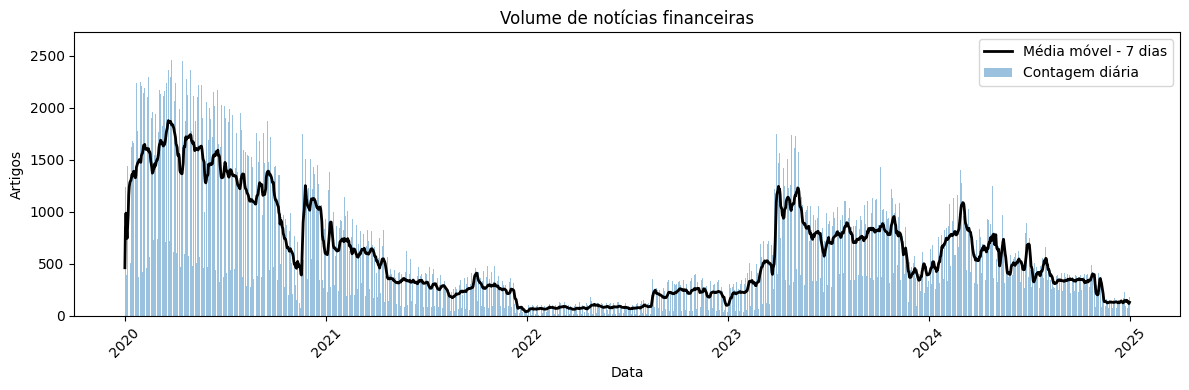

In [3]:
files = DAILY_DIRECTORY.glob("*.parquet")
df = pl.scan_parquet(files)

fin_df = (
    df
    .filter(
        pl.any_horizontal(
            pl.col("source").str.contains(r"cnbc.com|reuters.com|(?:^|\.)bloomberg.com"),
            (pl.col("url").str.contains(r"finance\.yahoo") & pl.col("source").str.contains("yahoo.com"))
        )
    )
    .with_columns(pl.col("datetime").dt.date().alias("date"))
)

daily_counts = fin_df.filter(pl.col("datetime").dt.year() <= 2024).group_by("date").len().sort("date")
result = daily_counts.collect(engine="streaming")
result_pd = result.to_pandas()
result_pd["rolling_7d"] = result_pd["len"].rolling(7, min_periods=1).mean()

print(fin_df.group_by("source").len().sort(by="len", descending=True).collect(engine="streaming"))

plt.figure(figsize=(12, 4))
plt.bar(result_pd["date"], result_pd["len"], label="Contagem diária", alpha=0.45)
plt.plot(result_pd["date"], result_pd["rolling_7d"], color="black", linewidth=2, label="Média móvel - 7 dias")
plt.title("Volume de notícias financeiras")
plt.xticks(rotation=45)
plt.xlabel("Data")
plt.ylabel("Artigos")
plt.legend()
plt.tight_layout()
plt.show()


shape: (6, 2)
┌───────────────────────┬───────┐
│ source                ┆ len   │
│ ---                   ┆ ---   │
│ str                   ┆ u32   │
╞═══════════════════════╪═══════╡
│ reuters.com           ┆ 21000 │
│ yahoo.com             ┆ 15343 │
│ bloomberg.com         ┆ 1336  │
│ cnbc.com              ┆ 1151  │
│ thomsonreuters.com    ┆ 3     │
│ thomsonreuters.com.au ┆ 1     │
└───────────────────────┴───────┘


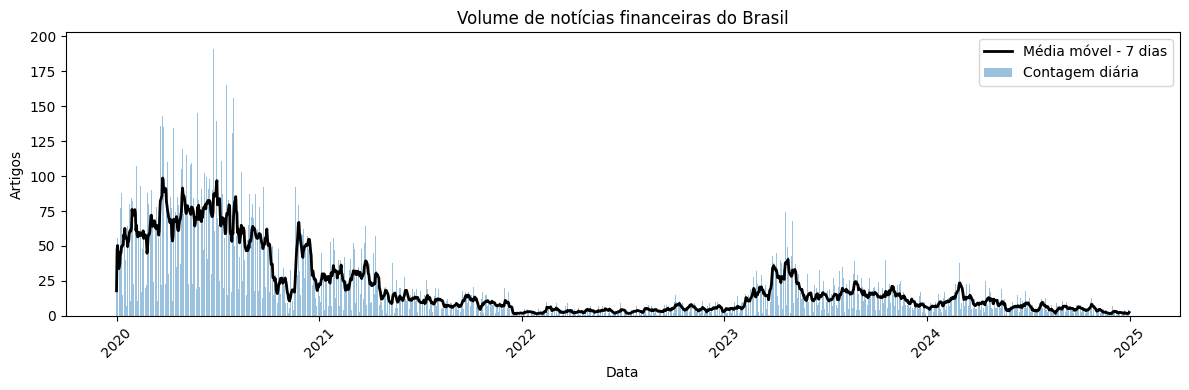

In [4]:
FILTERED_BRAZIL_PATH = Path("brazil_news")
FILTERED_BRAZIL_PATH.mkdir(exist_ok=True)

if not (FILTERED_BRAZIL_PATH / "brazil.parquet").exists():
    brazil_news = (
        fin_df
        .filter(
            pl.any_horizontal(
                pl.col("locations", "url", "themes", "v2themes", "title").str.contains_any(["brazil"], ascii_case_insensitive=True)
            )
        )
        .drop("date")
        .drop_nulls("title")
        .collect(engine="streaming")
    )

    brazil_news.write_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_counts = (
    brazil_news
    .filter(pl.col("datetime").dt.year() <= 2024)
    .with_columns(pl.col("datetime").dt.date().alias("date"))
    .group_by("date")
    .len()
    .sort("date")
)

brazil_counts_pd = brazil_counts.to_pandas()
brazil_counts_pd["rolling_7d"] = brazil_counts_pd["len"].rolling(7, min_periods=1).mean()

print(brazil_news.group_by("source").len().sort(by="len", descending=True))

plt.figure(figsize=(12, 4))
plt.bar(brazil_counts_pd["date"], brazil_counts_pd["len"], label="Contagem diária", alpha=0.45)
plt.plot(brazil_counts_pd["date"], brazil_counts_pd["rolling_7d"], color="black", linewidth=2, label="Média móvel - 7 dias")
plt.title("Volume de notícias financeiras do Brasil")
plt.xticks(rotation=45)
plt.xlabel("Data")
plt.ylabel("Artigos")
plt.legend()
plt.tight_layout()
plt.show()


# Modelagem


## Extração de sentimento dos títulos com FinBERT


In [5]:
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
device = torch.device("cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [6]:
labels = ("negative", "neutral", "positive")

In [7]:
def predict_sentiment(texts: list[str], batch_size=32):

    results: list[dict[str, float]] = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1).cpu()

        for p in probs:
            results.append({
                "negative": p[0],
                "neutral": p[1],
                "positive": p[2],
                "sentiment_score": (p[2] - p[0])/(p[2] + p[0])
            })

    return results

In [8]:
if not "sentiment_score" in brazil_news.columns:

    titles = brazil_news["title"].to_list()

    sentiments = []

    BATCH_SIZE = 2048

    for i in tqdm(range(0, len(titles), BATCH_SIZE)):
        batch = titles[i:i+BATCH_SIZE]
        sentiments.extend(predict_sentiment(batch))
    
    sentiment_df = pl.DataFrame(sentiments)

    brazil_news = brazil_news.with_columns(sentiment_df)
    brazil_news.write_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

## Download do Ibovespa de 2020 a 2025


In [9]:
ibov = pl.from_pandas(yf.download("^BVSP", start="2020-01-01", end="2026-01-01", progress=False, multi_level_index=False).reset_index())
ibov = ibov.rename({col:col.lower() for col in ibov.columns})

ibov = ibov.with_columns([
    pl.col("date").cast(pl.Date),
])

## Engenharia de variáveis


In [10]:
# Aggregate Brazil news daily

daily_news = (
    brazil_news.with_columns(pl.col("datetime").dt.date().alias("date"))
    .group_by("date")
    .agg([
        pl.len().alias("news_volume"),
        pl.col("sentiment_score").mean().alias("sentiment_mean"),
        pl.col("positive").mean().alias("positive_mean"),
        pl.col("negative").mean().alias("negative_mean"),
        pl.col("tone").mean().alias("tone"),
    ])
    .with_columns((pl.col("positive_mean") - pl.col("negative_mean")).alias("sentiment_imbalance"))
    .sort("date")
)

HORIZONS = list(range(1, 6))
news_cols = ["news_volume", "sentiment_mean", "positive_mean", "negative_mean", "tone", "sentiment_imbalance"]
price_feature_cols = ["return", "momentum_5d", "volatility_5d", "trend_20d", "drawdown_20d"]
target_cols = [f"target_return_{h}d" for h in HORIZONS] + [f"target_direction_{h}d" for h in HORIZONS]
required_model_cols = price_feature_cols + target_cols

dataset = (
    ibov
    .join(daily_news, on="date", how="left")
    .sort("date")
    .with_columns([pl.col(c).fill_null(0) for c in news_cols])
    .with_columns([
        (pl.col("close") / pl.col("close").shift(1) - 1).alias("return"),
        (pl.col("news_volume") + 1).log().alias("log_news_volume"),
    ])
    .with_columns([
        pl.col("return").rolling_mean(5).alias("momentum_5d"),
        pl.col("return").rolling_std(5).alias("volatility_5d"),
        (pl.col("close") / pl.col("close").rolling_mean(20) - 1).alias("trend_20d"),
        (pl.col("close") / pl.col("close").rolling_max(20) - 1).alias("drawdown_20d"),
        *[(pl.col("close").shift(-h) / pl.col("close") - 1).alias(f"target_return_{h}d") for h in HORIZONS],
    ])
    .with_columns([(pl.col(f"target_return_{h}d") > 0).cast(pl.Int8).alias(f"target_direction_{h}d") for h in HORIZONS])
    .with_columns([
        pl.col("target_return_1d").alias("target_return"),
        pl.col("target_direction_1d").alias("target_direction"),
    ])
)

# Shift news features one trading day to avoid using same-day information.
lagged_news_cols = news_cols + ["log_news_volume"]

pdf = (
    dataset
    .with_columns([pl.col(c).shift(1) for c in lagged_news_cols])
    .drop_nulls(subset=required_model_cols)
    .to_pandas()
)


### Seleção de variáveis para treino e previsão


In [11]:
sentiment_features = [
    "sentiment_mean",
    "sentiment_imbalance",
    "log_news_volume",
]

gdelt_tone_features = [
    "tone",
]

price_features = [
    "return",
    "momentum_5d",
    "volatility_5d",
    "trend_20d",
    "drawdown_20d",
]


### Funções para classificação e regressão


In [12]:
tscv = TimeSeriesSplit(n_splits=5)
CLASSIFICATION_METRICS = ["accuracy_mean", "f1_mean", "roc_auc_mean"]
REGRESSION_METRICS = ["rmse_mean", "mae_mean", "r2_mean"]


def scale_train_test(X_train, X_test):
    scaler = StandardScaler()
    return (
        pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index),
        pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index),
    )


class TabularMLP(nn.Module):
    def __init__(self, n_features, hidden_size=16, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_features, hidden_size), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_size, 1))

    def forward(self, x):
        return self.net(x).squeeze(-1)


class MLPModel:
    def __init__(self, task, hidden_size=16, dropout=0.2, lr=1e-3, weight_decay=1e-4, epochs=100, patience=10, random_state=42):
        self.__dict__.update(locals())
        del self.__dict__["self"]

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        self.model_ = TabularMLP(X.shape[1], self.hidden_size, self.dropout)
        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        criterion = nn.BCEWithLogitsLoss() if self.task == "classification" else nn.MSELoss()
        X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
        y_tensor = torch.tensor(np.asarray(y), dtype=torch.float32)
        split_idx = max(1, int(len(X_tensor) * 0.8))
        train = X_tensor[:split_idx], y_tensor[:split_idx]
        val = X_tensor[split_idx:], y_tensor[split_idx:]
        best_loss, best_state, wait = float("inf"), None, 0

        for _ in range(self.epochs):
            self.model_.train()
            optimizer.zero_grad()
            loss = criterion(self.model_(train[0]), train[1])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model_.parameters(), max_norm=1.0)
            optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss = criterion(self.model_(val[0]), val[1]).item() if len(val[0]) else loss.item()
            if val_loss < best_loss:
                best_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in self.model_.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= self.patience:
                    break

        if best_state:
            self.model_.load_state_dict(best_state)
        return self

    def _predict_raw(self, X):
        self.model_.eval()
        with torch.no_grad():
            return self.model_(torch.tensor(X.to_numpy(), dtype=torch.float32)).numpy()

    def predict(self, X):
        raw = self._predict_raw(X)
        return (1 / (1 + np.exp(-raw)) >= 0.5).astype(int) if self.task == "classification" else raw

    def predict_proba(self, X):
        proba = 1 / (1 + np.exp(-self._predict_raw(X)))
        return np.column_stack([1 - proba, proba])


def make_classifiers(include_mlp=True):
    models = {
        "log_reg": LogisticRegression(max_iter=2000),
        "rf_clas": RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1),
        "xgb_clas": XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8),
    }
    if include_mlp:
        models["mlp_clas"] = MLPModel(task="classification")
    return models


def make_regressors(include_mlp=True):
    models = {
        "lin_reg": LinearRegression(n_jobs=-1),
        "rf_reg": RandomForestRegressor(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1),
        "xgb_reg": XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03),
    }
    if include_mlp:
        models["mlp_reg"] = MLPModel(task="regression")
    return models


def summarize_metrics(fold_metrics):
    fold_df = pd.DataFrame(fold_metrics)
    return {f"{metric}_{stat}": getattr(fold_df[metric], stat)() for metric in fold_df.columns for stat in ("mean", "std")}


def run_cv(model, X, y, metric_fn, prediction_fn):
    fold_metrics, y_true, y_pred, extra = [], [], [], []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = scale_train_test(X.iloc[train_idx], X.iloc[test_idx])
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_train, y_train)
        pred, extra_pred = prediction_fn(model, X_test)
        fold_metrics.append(metric_fn(y_test, pred, extra_pred))
        y_true.append(y_test)
        y_pred.append(pred)
        if extra_pred is not None:
            extra.append(extra_pred)
    return summarize_metrics(fold_metrics), pd.concat(y_true), np.concatenate(y_pred), extra


def run_classification(model, X, y):
    def predict(model, X_test):
        proba = model.predict_proba(X_test)[:, 1]
        return model.predict(X_test), proba

    def metrics(y_test, pred, proba):
        return {"accuracy": accuracy_score(y_test, pred), "f1": f1_score(y_test, pred), "roc_auc": roc_auc_score(y_test, proba)}

    summary, y_true, y_pred, proba = run_cv(model, X, y, metrics, predict)
    return summary, y_true, y_pred, np.concatenate(proba)


def run_regression(model, X, y):
    def predict(model, X_test):
        return model.predict(X_test), None

    def metrics(y_test, pred, _):
        return {"rmse": root_mean_squared_error(y_test, pred), "mae": mean_absolute_error(y_test, pred), "r2": r2_score(y_test, pred)}

    summary, y_true, y_pred, _ = run_cv(model, X, y, metrics, predict)
    return summary, y_true, y_pred


def evaluate_models(X, y_cls, y_reg, classifiers=None, regressors=None):
    results, importances = {}, {}
    for task, models, runner, y, sort_col in [
        ("clf", classifiers or make_classifiers(), run_classification, y_cls, "accuracy_mean"),
        ("reg", regressors or make_regressors(), run_regression, y_reg, "r2_mean"),
    ]:
        rows, imps = [], {}
        for name, model in models.items():
            metrics, *_ = runner(model, X, y)
            rows.append({"model": name, **metrics})
            if hasattr(model, "feature_importances_"):
                imps[name] = pd.Series(model.feature_importances_, index=X.columns)
        results[task] = pd.DataFrame(rows).sort_values(sort_col, ascending=False)
        importances[task] = imps
    return results["clf"], results["reg"], importances["clf"], importances["reg"]


def regression_baselines(y):
    zero_pred = np.zeros(len(y))
    return {"rmse_mean": root_mean_squared_error(y, zero_pred), "mae_mean": mean_absolute_error(y, zero_pred), "r2_mean": r2_score(y, zero_pred)}


def style_axis(ax, title, xlabel=None, ylabel=None, grid_axis="y"):
    ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, alpha=0.3)


def plot_metric_bars(ax, df, metric_cols, title):
    x, width = np.arange(len(df)), 0.8 / len(metric_cols)
    for i, col in enumerate(metric_cols):
        ax.bar(x + (i - (len(metric_cols) - 1) / 2) * width, df[col], width, yerr=df.get(col.replace("_mean", "_std")), capsize=4, label=col.replace("_mean", "").upper())
    ax.set_xticks(x, df["model"])
    ax.legend(title="Metric")
    style_axis(ax, title, "Modelo", "Métrica")


def plot_single_metric_bar(ax, df, metric, title, baseline=None):
    ax.bar(df["model"], df[metric], yerr=df.get(metric.replace("_mean", "_std")), capsize=4)
    if baseline is not None:
        ax.axhline(baseline, color="black", linestyle="--", linewidth=1, label="Baseline")
        ax.legend()
    ax.tick_params(axis="x", rotation=20)
    style_axis(ax, title, "Modelo", metric.replace("_mean", "").upper())


def plot_importance(ax, importance, title, top_n=15):
    if importance:
        pd.concat(importance, axis=1).fillna(0).mean(axis=1).sort_values(ascending=False).head(top_n).plot.bar(ax=ax)
    style_axis(ax, title)


def plot_horizon_heatmap(ax, df, metric, title):
    table = df.pivot_table(index="horizon", columns="model", values=metric)
    image = ax.imshow(table.values, aspect="auto")
    ax.set_xticks(range(len(table.columns)), table.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(table.index)), [f"{h}d" for h in table.index])
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            ax.text(col, row, f"{table.iloc[row, col]:.3f}", ha="center", va="center", fontsize=8)
    plt.colorbar(image, ax=ax, label=metric)
    style_axis(ax, title, "Modelo", "Horizonte")


def evaluate_horizons(X, target_sets):
    clf_rows, reg_rows = [], []
    first_importance = None
    for horizon, (y_dir, y_ret) in target_sets.items():
        clf_df, reg_df, clf_importance, reg_importance = evaluate_models(X, y_dir, y_ret)
        clf_rows.append(clf_df.assign(horizon=horizon))
        reg_rows.append(reg_df.assign(horizon=horizon))
        first_importance = first_importance or (clf_importance, reg_importance)
    return pd.concat(clf_rows, ignore_index=True), pd.concat(reg_rows, ignore_index=True), *first_importance


def plot_model_results(feature_cols, title, target_sets):
    clf_df, reg_df, clf_importance, reg_importance = evaluate_horizons(pdf[feature_cols], target_sets)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title)
    plot_horizon_heatmap(axes[0, 0], clf_df, "roc_auc_mean", "ROC AUC - classificação")
    plot_horizon_heatmap(axes[0, 1], clf_df, "accuracy_mean", "Acurácia - classificação")
    plot_horizon_heatmap(axes[0, 2], reg_df, "rmse_mean", "RMSE - regressão")
    plot_horizon_heatmap(axes[1, 0], reg_df, "r2_mean", "R² - regressão")
    plot_importance(axes[1, 1], clf_importance, "Importância das variáveis (1 dia) - classificadores de árvore")
    plot_importance(axes[1, 2], reg_importance, "Importância das variáveis (1 dia) - regressores de árvore")
    plt.tight_layout()
    plt.show()
    return clf_df, reg_df, clf_importance, reg_importance


def collect_experiment_results(experiments):
    rows = {"clf": [], "reg": []}
    for experiment, result in experiments.items():
        clf_df, reg_df = result[:2]
        rows["clf"].append(clf_df.assign(experiment=experiment))
        rows["reg"].append(reg_df.assign(experiment=experiment))
    return pd.concat(rows["clf"], ignore_index=True), pd.concat(rows["reg"], ignore_index=True)


def rank_experiments(experiments, classifier_metric="roc_auc_mean", regressor_metric="rmse_mean"):
    clf_results, reg_results = collect_experiment_results(experiments)
    clf_cols = list(dict.fromkeys(["experiment", "horizon", "model", classifier_metric, *CLASSIFICATION_METRICS]))
    reg_cols = list(dict.fromkeys(["experiment", "horizon", "model", regressor_metric, *REGRESSION_METRICS]))
    return (
        clf_results.sort_values(classifier_metric, ascending=False).loc[:, clf_cols].reset_index(drop=True),
        reg_results.sort_values(regressor_metric).loc[:, reg_cols].reset_index(drop=True),
        clf_results,
        reg_results,
    )


def plot_result_heatmap(ax, results, metric, title):
    table = results.pivot_table(index=["experiment", "horizon"], columns="model", values=metric)
    image = ax.imshow(table.values, aspect="auto")
    labels = [f"{experiment} | {horizon}d" for experiment, horizon in table.index]
    ax.set_xticks(range(len(table.columns)), table.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(table.index)), labels)
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            ax.text(col, row, f"{table.iloc[row, col]:.3f}", ha="center", va="center", fontsize=7)
    plt.colorbar(image, ax=ax, label=metric)
    style_axis(ax, title)


def plot_top_results(ax, ranking, metric, title, top_n=10):
    top = ranking.head(top_n)
    labels = top["experiment"].astype(str) + " | " + top["horizon"].astype(str) + "d | " + top["model"].astype(str)
    ax.barh(np.arange(len(top)), pd.to_numeric(top[metric], errors="coerce"))
    ax.set_yticks(np.arange(len(top)), labels)
    ax.invert_yaxis()
    style_axis(ax, title, metric, grid_axis="x")


def plot_experiment_comparison(experiments, title="Comparação de experimentos"):
    clf_ranking, reg_ranking, clf_results, reg_results = rank_experiments(experiments)
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(title)
    plot_top_results(axes[0, 0], clf_ranking, "roc_auc_mean", "Melhores classificadores por ROC AUC")
    plot_top_results(axes[0, 1], reg_ranking, "rmse_mean", "Melhores regressores por RMSE")
    plot_result_heatmap(axes[1, 0], clf_results, "roc_auc_mean", "ROC AUC de classificação por experimento")
    plot_result_heatmap(axes[1, 1], reg_results, "rmse_mean", "RMSE de regressão por experimento")
    plt.tight_layout()
    plt.show()
    print("Ranking dos classificadores")
    display(clf_ranking)
    print("Ranking dos regressores")
    display(reg_ranking)
    return clf_ranking, reg_ranking, clf_results, reg_results


## Avaliação dos modelos


In [13]:
target_sets = {
    horizon: (pdf[f"target_direction_{horizon}d"], pdf[f"target_return_{horizon}d"])
    for horizon in HORIZONS
}

y_dir, y_ret = target_sets[1]


### Gráficos descritivos para os resultados


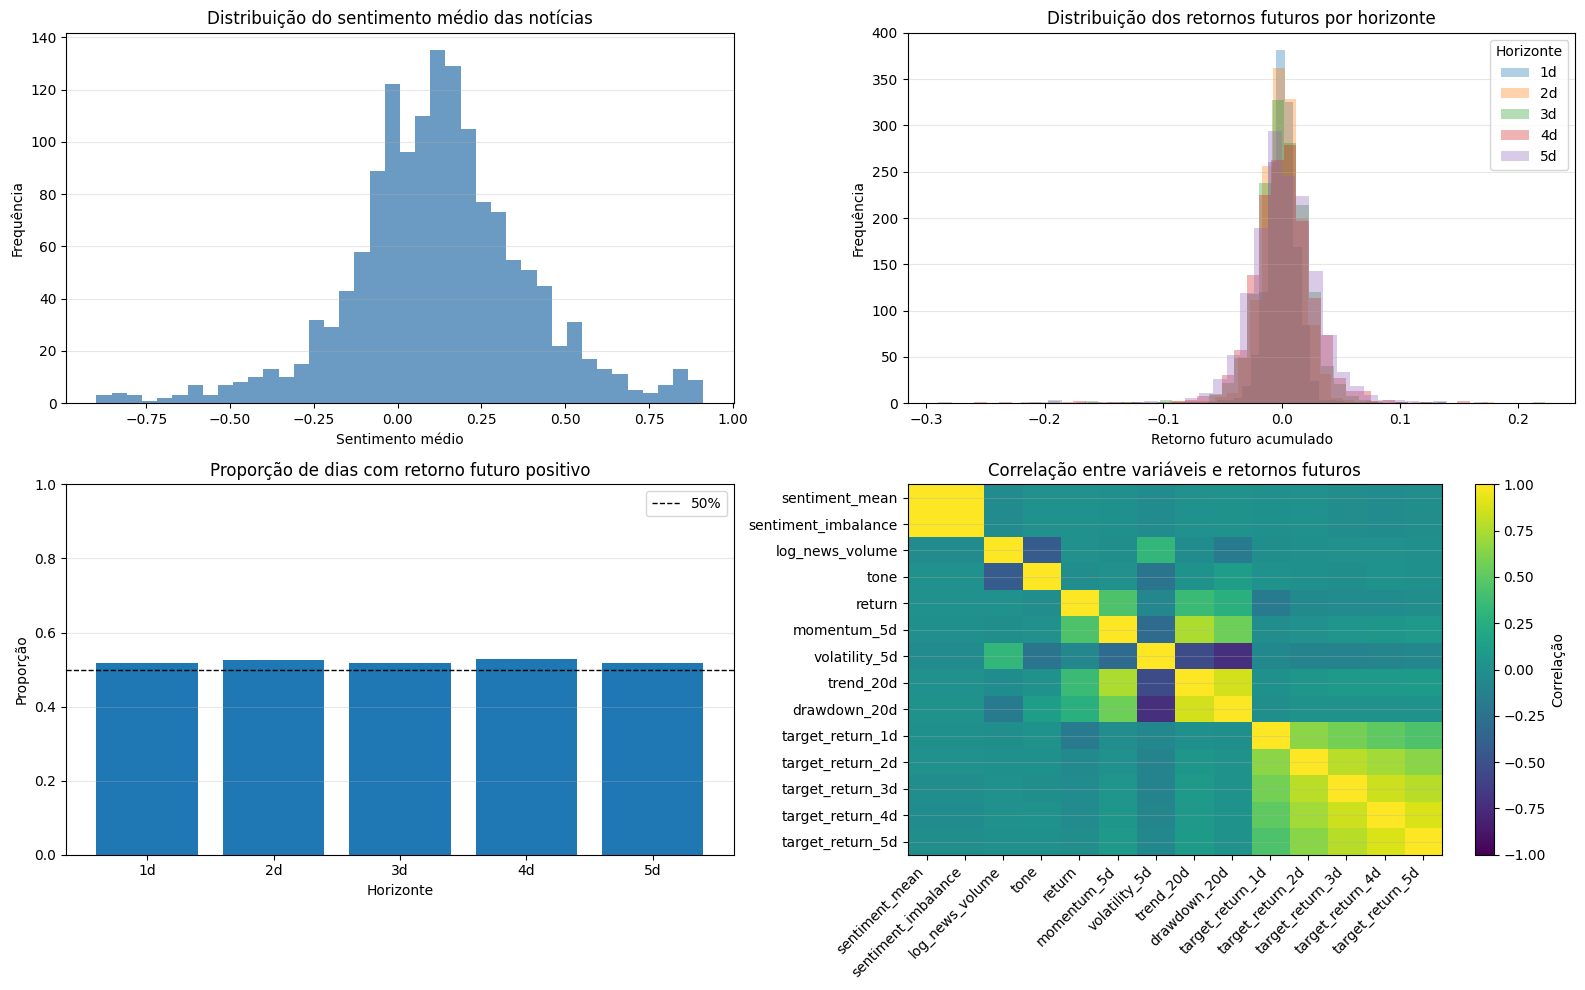

In [14]:
feature_cols = sentiment_features + gdelt_tone_features + price_features
return_cols = [f"target_return_{h}d" for h in HORIZONS]
direction_cols = [f"target_direction_{h}d" for h in HORIZONS]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(pdf["sentiment_mean"], bins=40, color="steelblue", alpha=0.8)
style_axis(axes[0, 0], "Distribuição do sentimento médio das notícias", "Sentimento médio", "Frequência")

for h, col in zip(HORIZONS, return_cols):
    axes[0, 1].hist(pdf[col], bins=40, alpha=0.35, label=f"{h}d")
style_axis(axes[0, 1], "Distribuição dos retornos futuros por horizonte", "Retorno futuro acumulado", "Frequência")
axes[0, 1].legend(title="Horizonte")

balance = pd.DataFrame({f"{h}d": pdf[f"target_direction_{h}d"].mean() for h in HORIZONS}, index=["Alta"]).T
axes[1, 0].bar(balance.index, balance["Alta"])
axes[1, 0].axhline(0.5, color="black", linestyle="--", linewidth=1, label="50%")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
style_axis(axes[1, 0], "Proporção de dias com retorno futuro positivo", "Horizonte", "Proporção")

corr = pdf[feature_cols + return_cols].corr()
image = axes[1, 1].imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
axes[1, 1].set_yticks(range(len(corr.index)), corr.index)
plt.colorbar(image, ax=axes[1, 1], label="Correlação")
style_axis(axes[1, 1], "Correlação entre variáveis e retornos futuros")

plt.tight_layout()
plt.show()


### Relação visual entre sentimento e retornos futuros


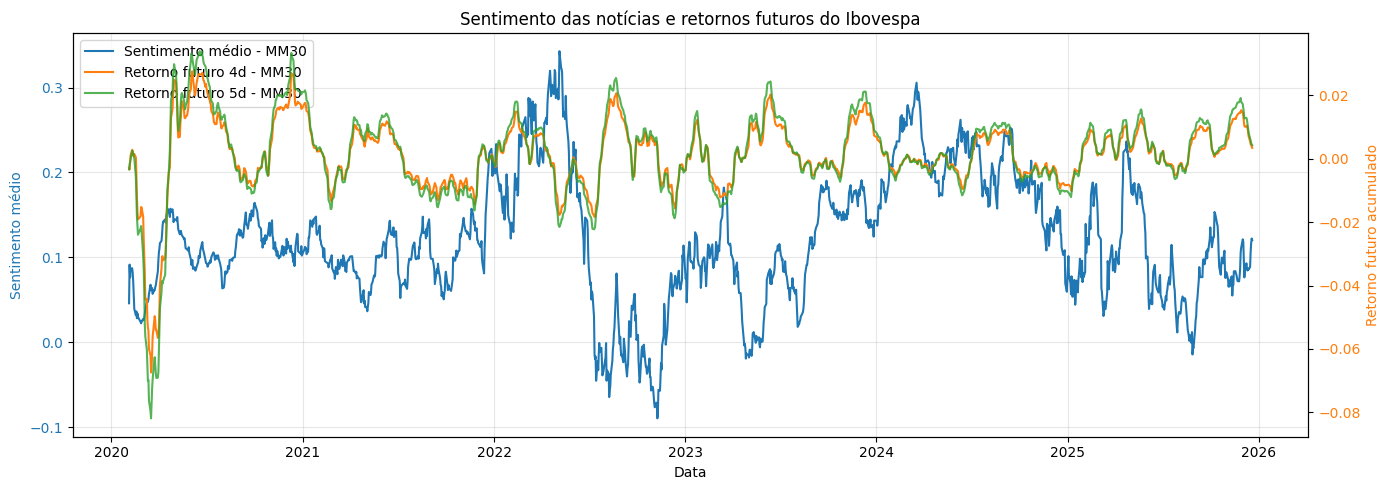

In [15]:
plot_df = pdf[["date", "sentiment_mean", "target_return_4d", "target_return_5d"]].copy()
plot_df["sentimento_mm30"] = plot_df["sentiment_mean"].rolling(30, min_periods=5).mean()
plot_df["retorno_4d_mm30"] = plot_df["target_return_4d"].rolling(30, min_periods=5).mean()
plot_df["retorno_5d_mm30"] = plot_df["target_return_5d"].rolling(30, min_periods=5).mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(plot_df["date"], plot_df["sentimento_mm30"], color="tab:blue", label="Sentimento médio - MM30")
ax1.set_ylabel("Sentimento médio", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(plot_df["date"], plot_df["retorno_4d_mm30"], color="tab:orange", label="Retorno futuro 4d - MM30")
ax2.plot(plot_df["date"], plot_df["retorno_5d_mm30"], color="tab:green", label="Retorno futuro 5d - MM30", alpha=0.8)
ax2.set_ylabel("Retorno futuro acumulado", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
ax1.set_title("Sentimento das notícias e retornos futuros do Ibovespa")
ax1.set_xlabel("Data")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Teste com apenas retorno


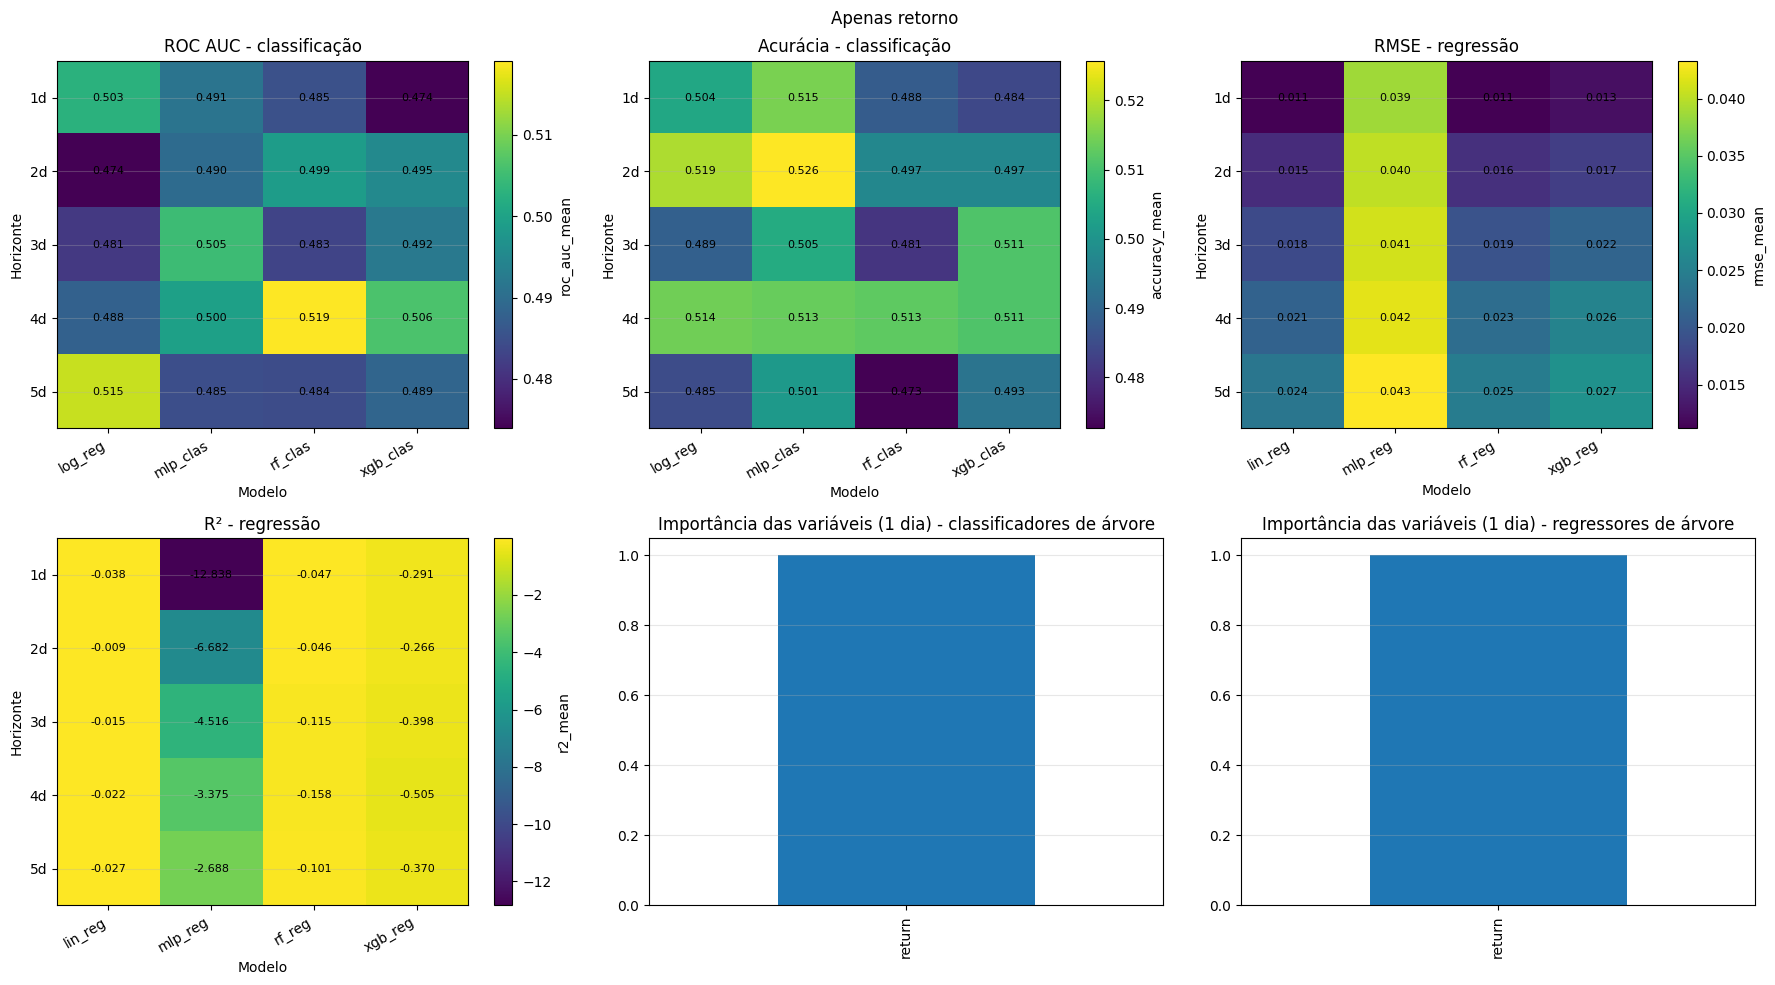

In [16]:
return_results = plot_model_results(["return"], "Apenas retorno", target_sets)


### Teste com apenas sentimento médio


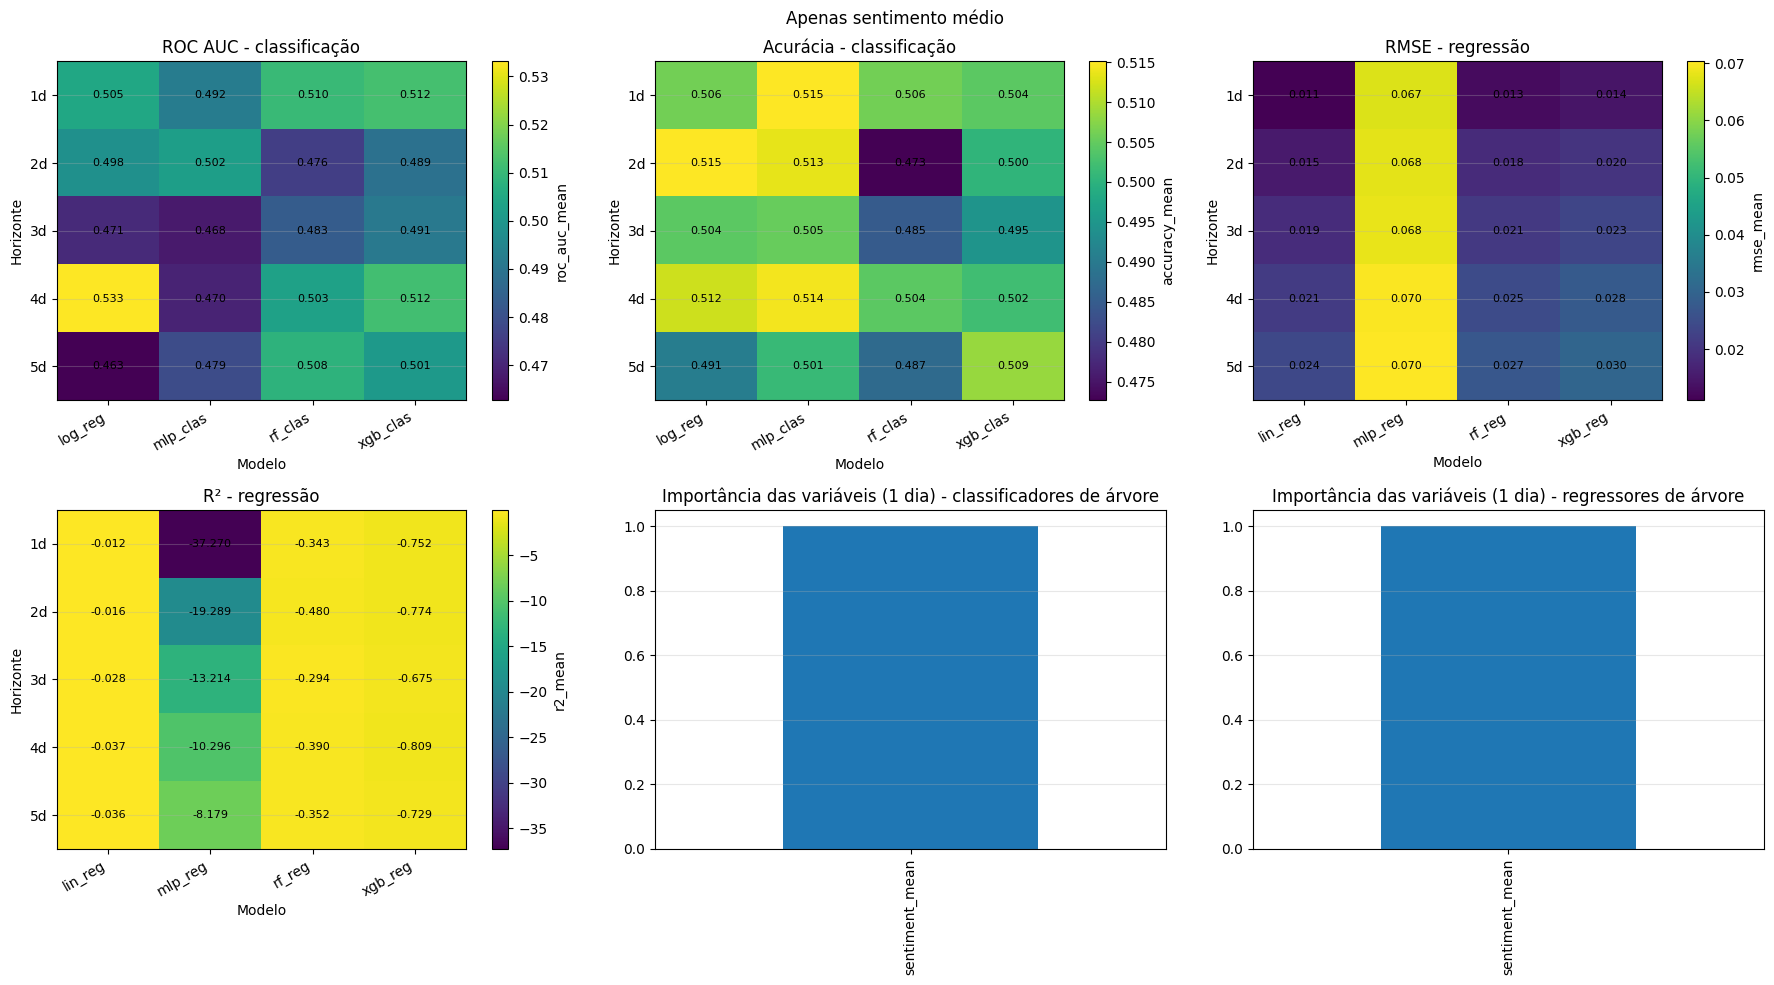

In [17]:
sentiment_mean_results = plot_model_results(["sentiment_mean"], "Apenas sentimento médio", target_sets)


### Teste com apenas tom GDELT


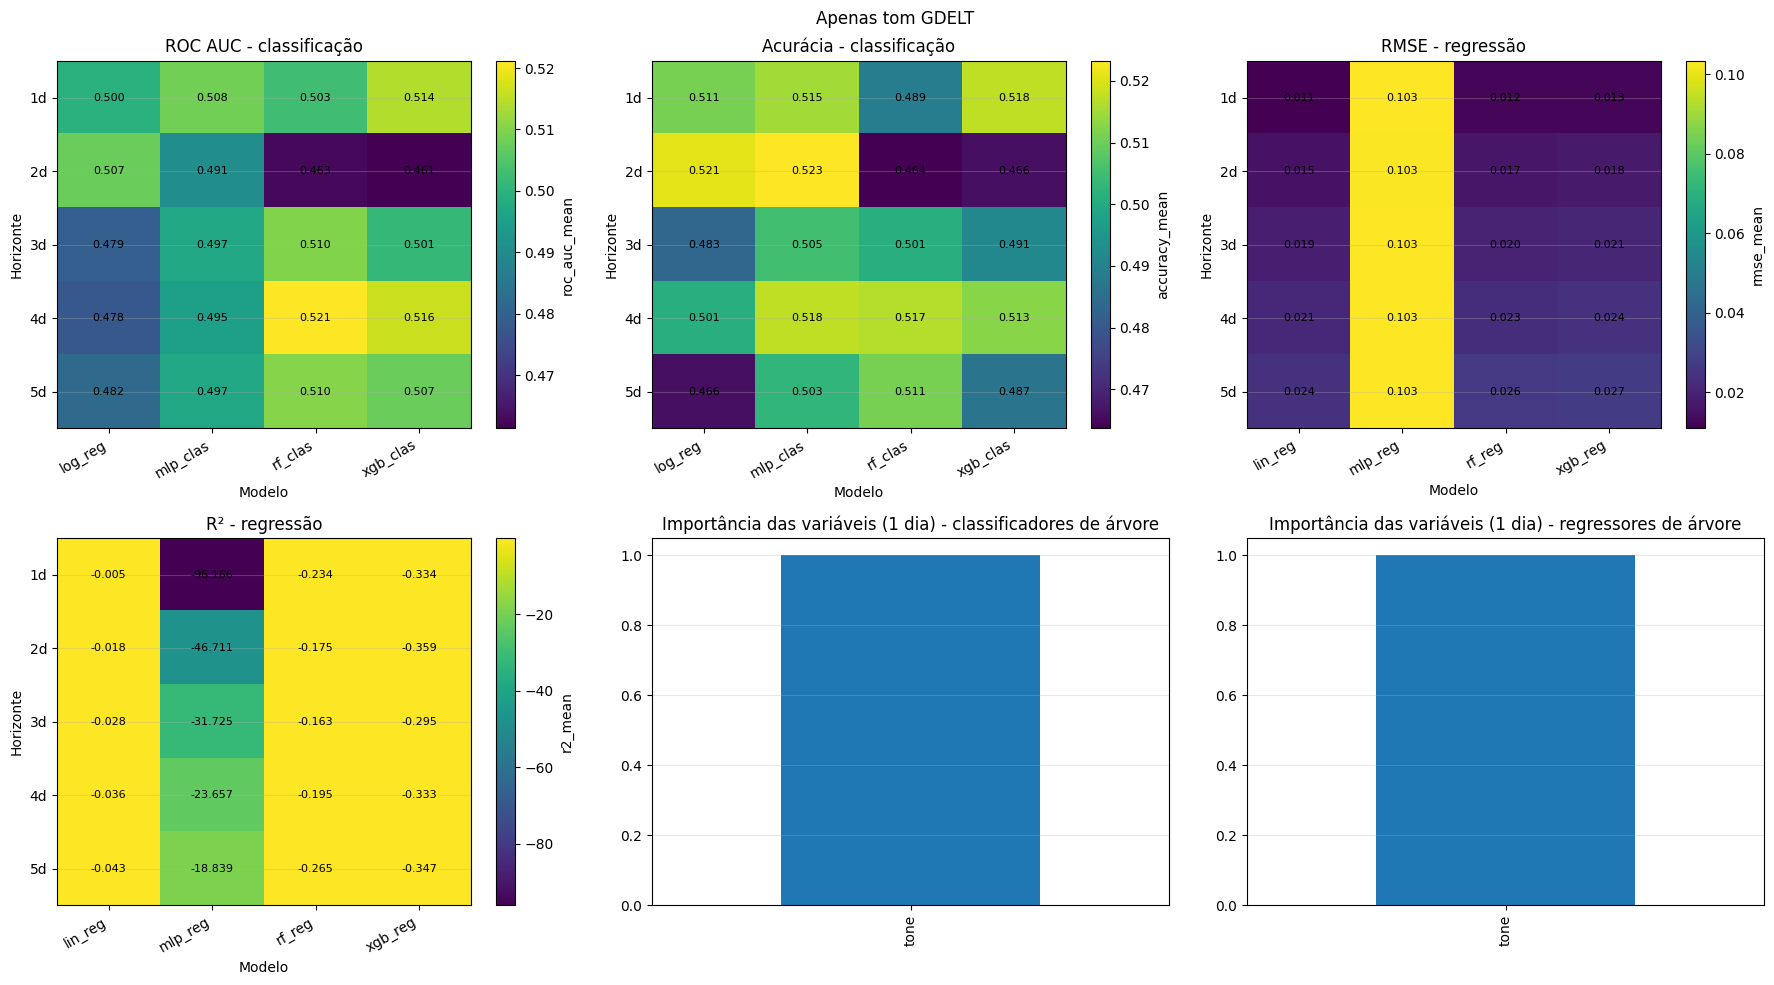

In [18]:
tone_results = plot_model_results(gdelt_tone_features, "Apenas tom GDELT", target_sets)


### Teste com variáveis de sentimento e notícias


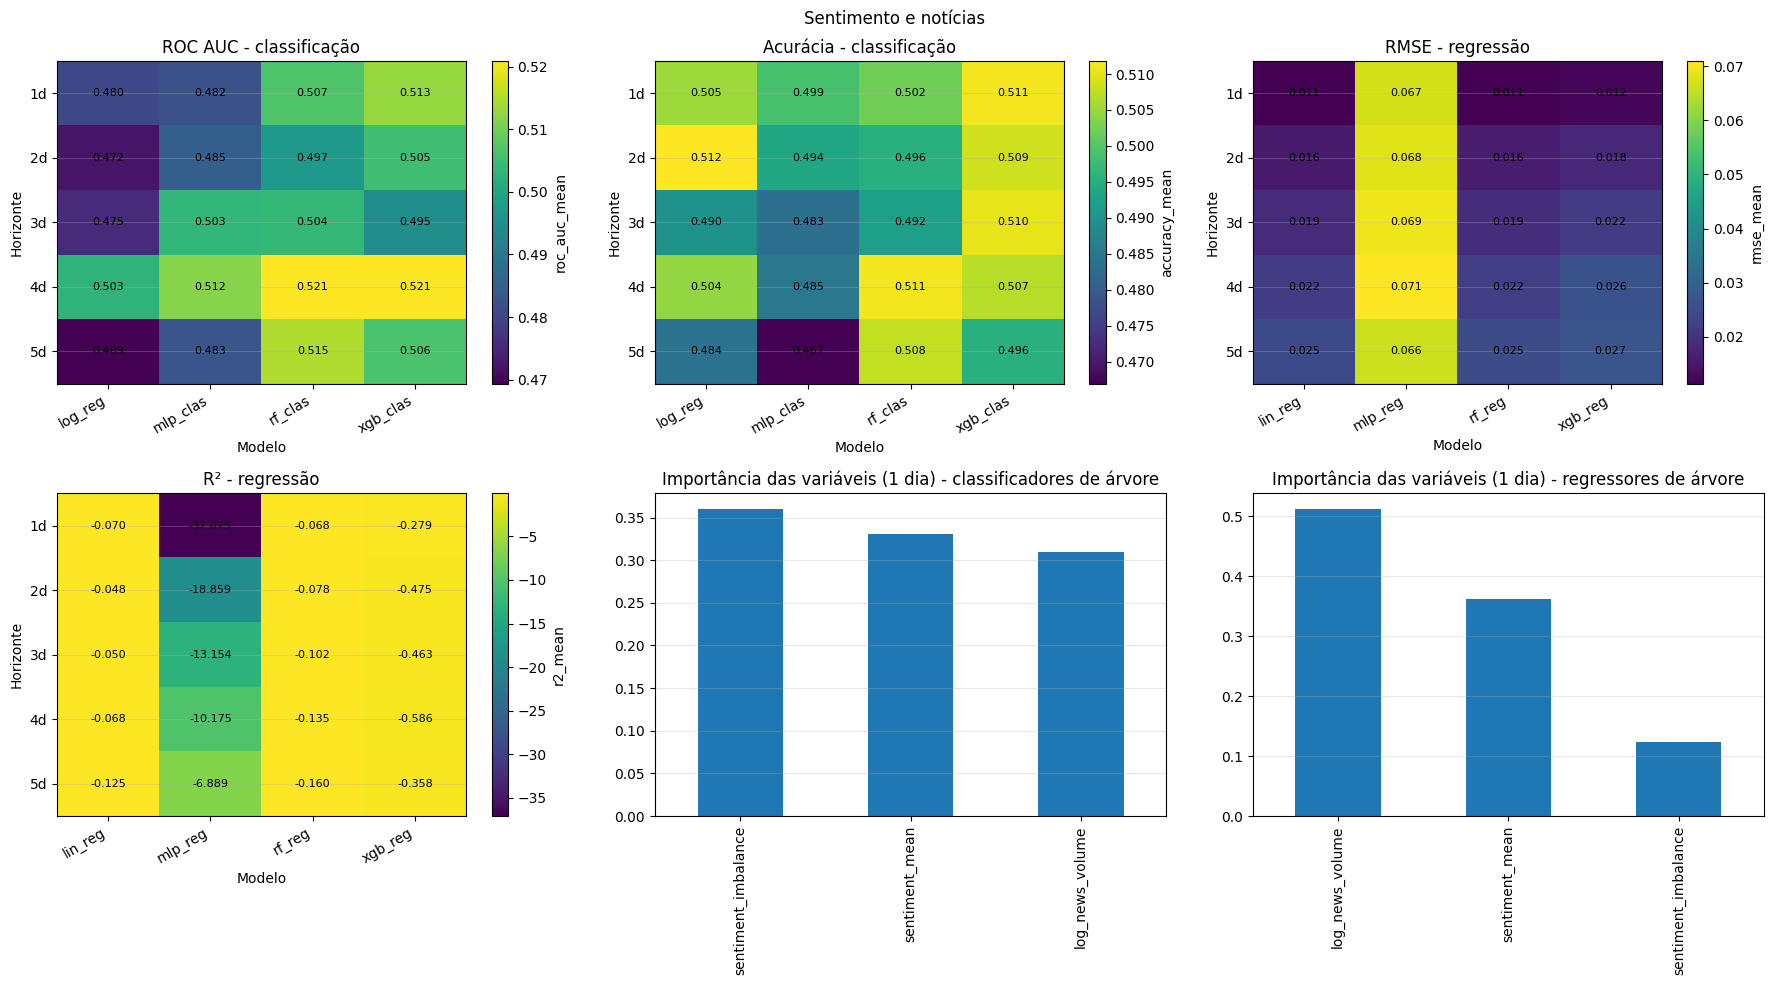

In [19]:
sentiment_results = plot_model_results(sentiment_features, "Sentimento e notícias", target_sets)


### Teste com variáveis de preço


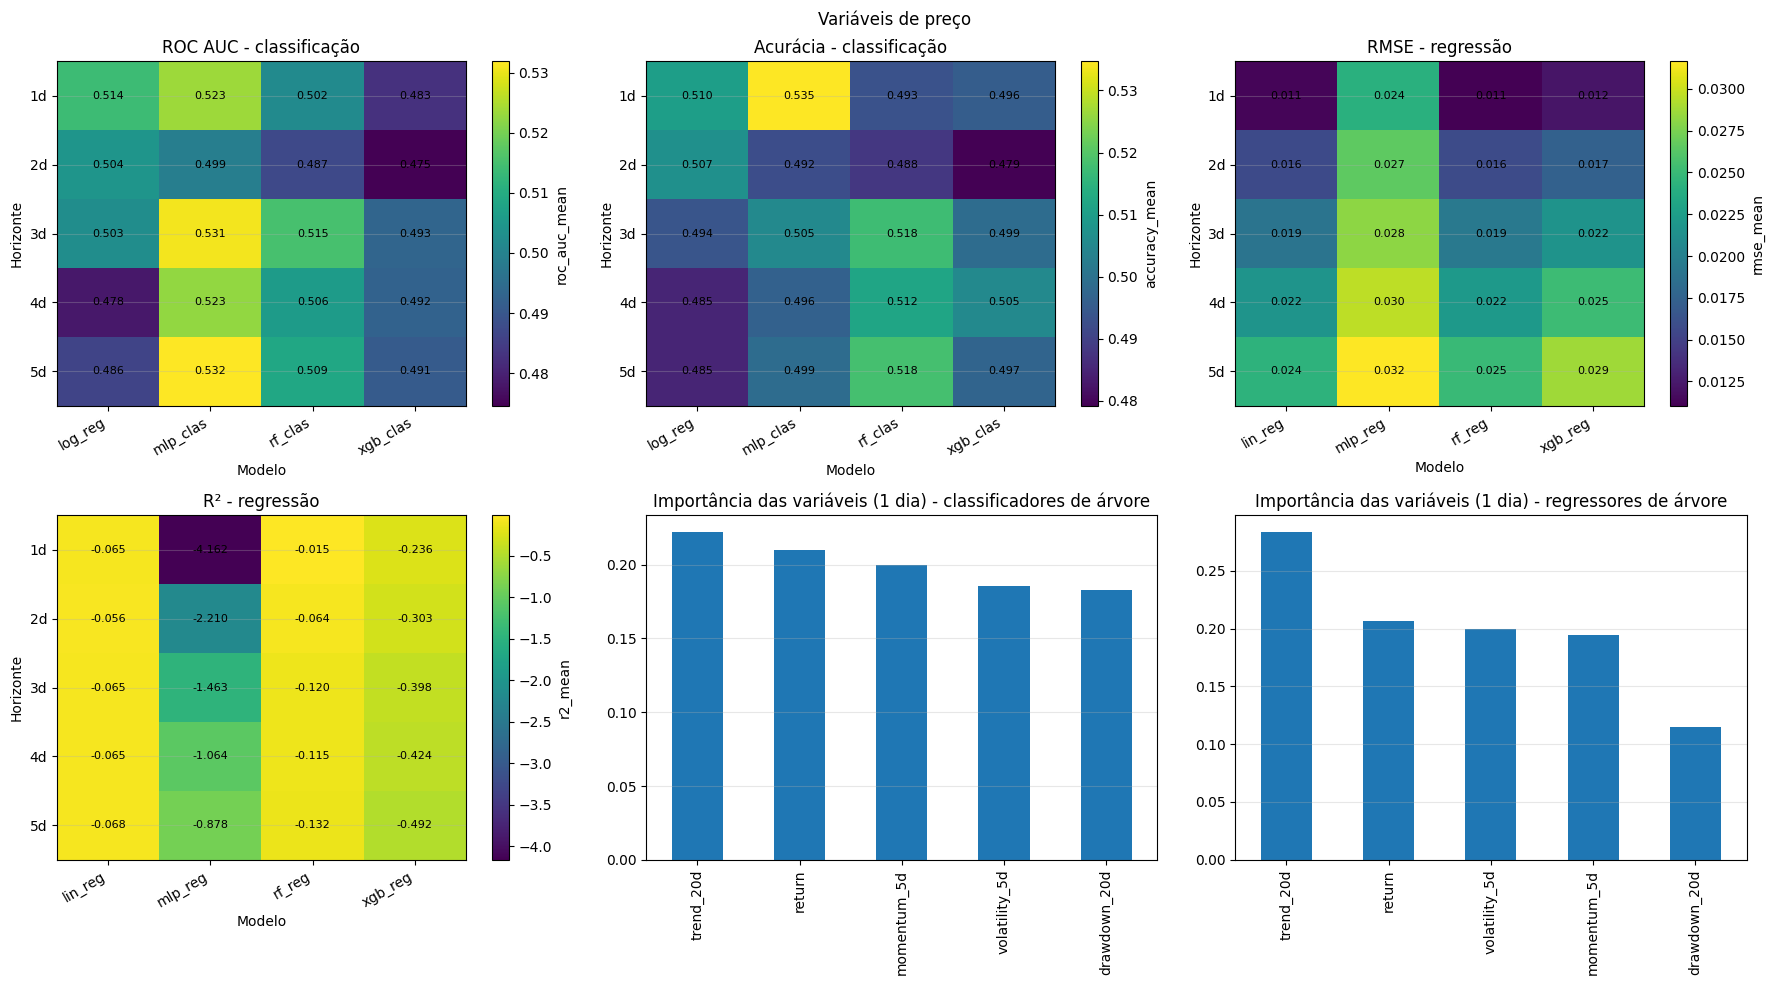

In [20]:
price_results = plot_model_results(price_features, "Variáveis de preço", target_sets)


### Teste com sentimento, tom e preço


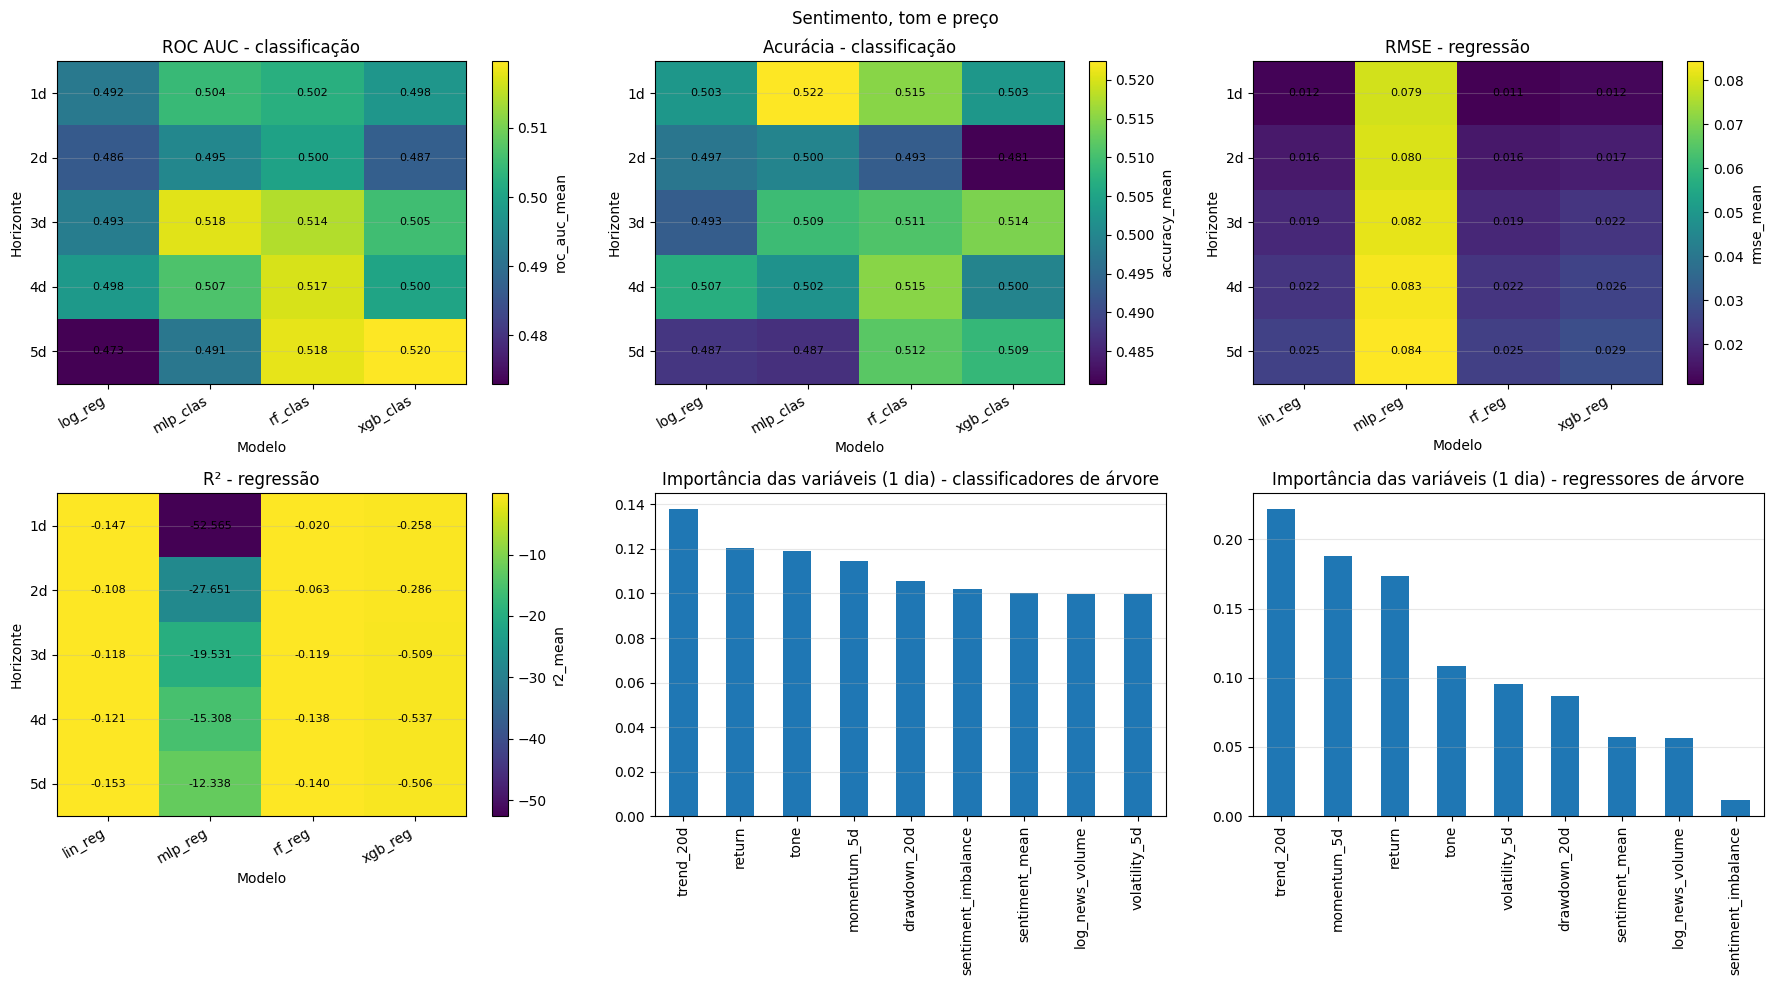

In [21]:
all_feature_results = plot_model_results(sentiment_features + gdelt_tone_features + price_features, "Sentimento, tom e preço", target_sets)


### Comparação dos testes padrão


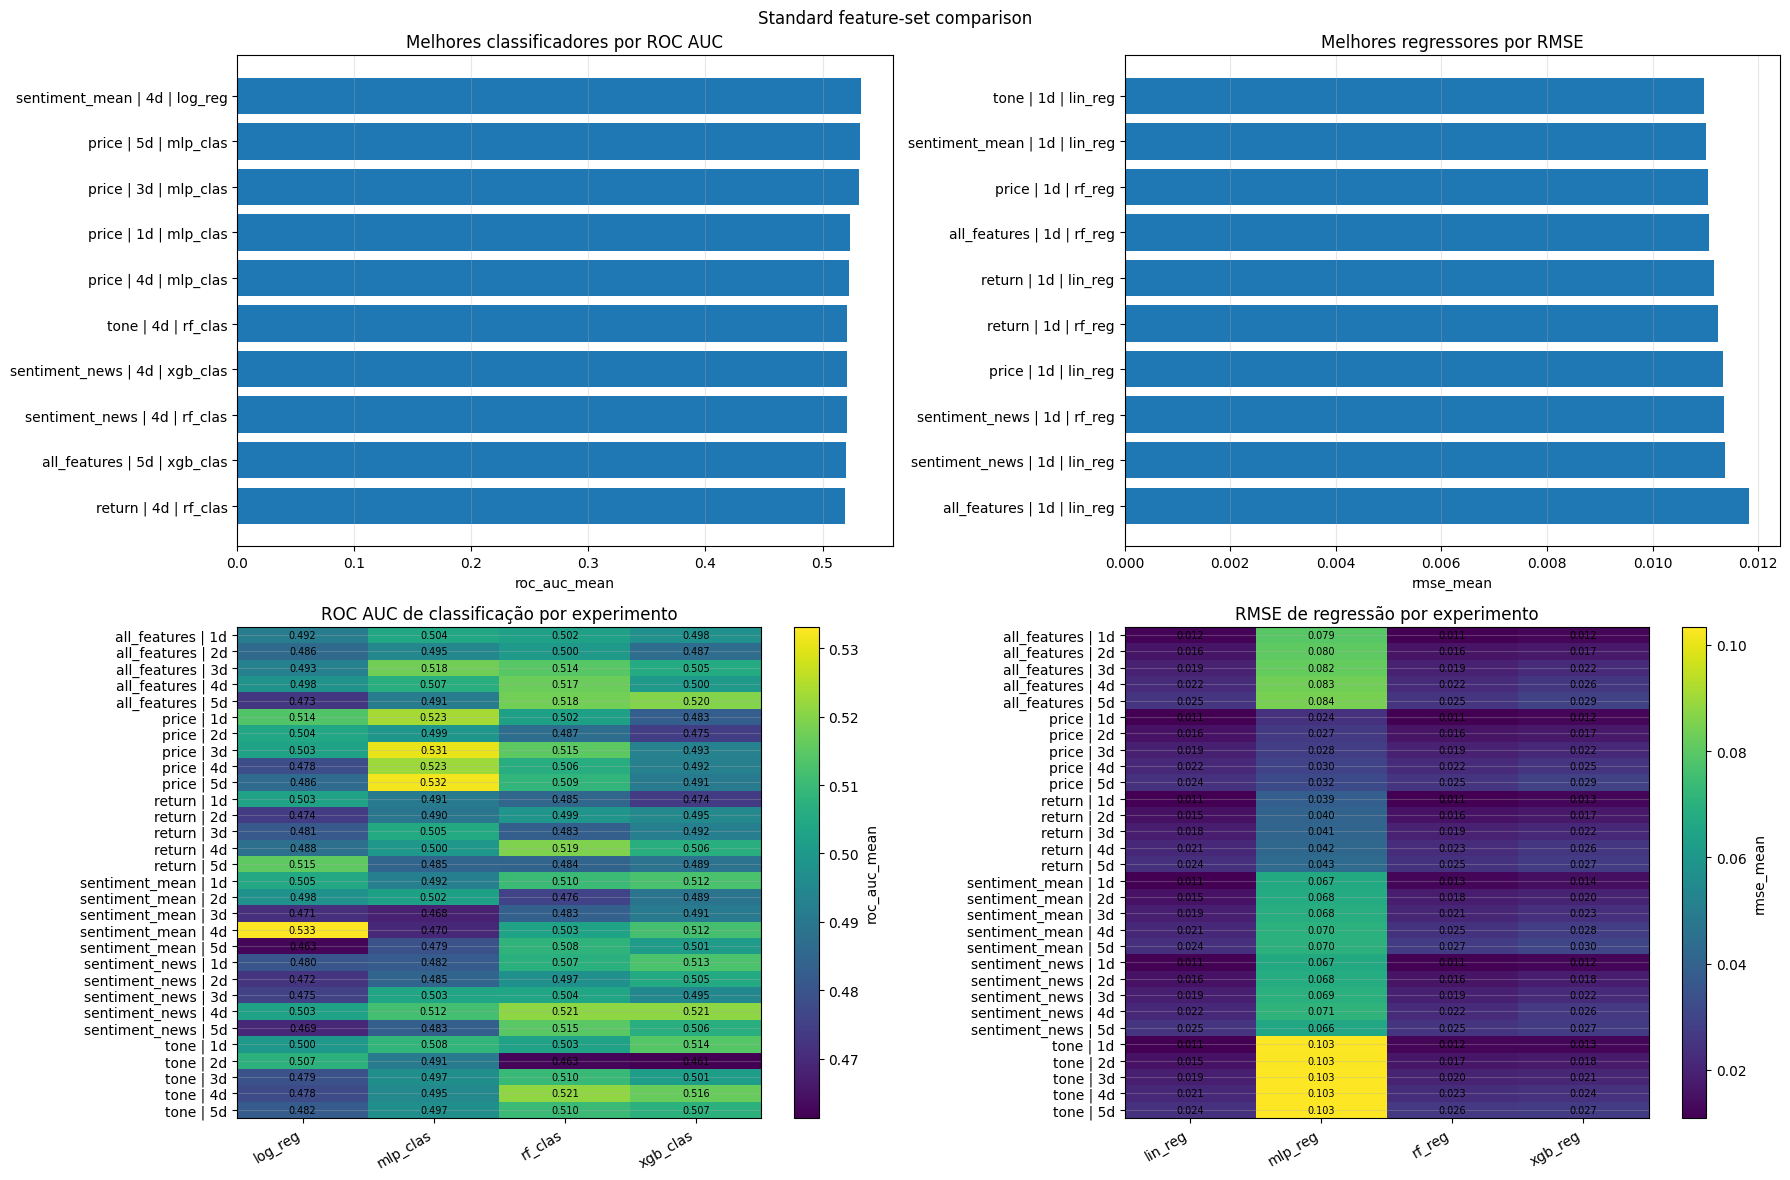

Ranking dos classificadores


,experiment,horizon,model,roc_auc_mean,accuracy_mean,f1_mean
0,sentiment_mean,4,log_reg,0.533130,0.511837,0.597052
1,price,5,mlp_clas,0.531864,0.498776,0.284479
2,price,3,mlp_clas,0.530818,0.505306,0.405885
3,price,1,mlp_clas,0.523474,0.534694,0.534505
4,price,4,mlp_clas,0.522557,0.496327,0.374953
...,...,...,...,...,...,...
115,sentiment_news,5,log_reg,0.469352,0.484082,0.490312
116,sentiment_mean,3,mlp_clas,0.467847,0.505306,0.670081
117,sentiment_mean,5,log_reg,0.462709,0.490612,0.584203
118,tone,2,rf_clas,0.462573,0.463673,0.491949


Ranking dos regressores


,experiment,horizon,model,rmse_mean,mae_mean,r2_mean
0,tone,1,lin_reg,0.010977,0.008509,-0.005125
1,sentiment_mean,1,lin_reg,0.011020,0.008535,-0.011723
2,price,1,rf_reg,0.011044,0.008535,-0.014900
3,all_features,1,rf_reg,0.011066,0.008542,-0.020231
4,return,1,lin_reg,0.011171,0.008757,-0.038412
...,...,...,...,...,...,...
115,tone,2,mlp_reg,0.102909,0.085020,-46.711009
116,tone,3,mlp_reg,0.103028,0.084828,-31.724658
117,tone,4,mlp_reg,0.103086,0.084730,-23.656766
118,tone,5,mlp_reg,0.103223,0.084247,-18.839498


In [22]:
standard_experiments = {
    "return": return_results,
    "sentiment_mean": sentiment_mean_results,
    "tone": tone_results,
    "sentiment_news": sentiment_results,
    "price": price_results,
    "all_features": all_feature_results,
}

standard_comparison = plot_experiment_comparison(standard_experiments, "Standard feature-set comparison")


## Seleção de variáveis com Recursive Feature Elimination


In [23]:
def run_rfecv(model, X, y, scoring):
    selector = RFECV(estimator=model, step=1, cv=TimeSeriesSplit(n_splits=5), scoring=scoring, n_jobs=-1)
    selector.fit(X, y)
    return selector


def get_feature_importance(model, feature_names):
    if hasattr(model, "coef_"):
        return pd.Series(np.abs(model.coef_).flatten(), index=feature_names)
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=feature_names)
    raise ValueError("Model does not expose feature importance")


def evaluate_rfecv_models(X, y_cls, y_reg):
    configs = [
        ("clf", make_classifiers(False), y_cls, "accuracy", run_classification, "accuracy_mean"),
        ("reg", make_regressors(False), y_reg, "neg_mean_squared_error", run_regression, "r2_mean"),
    ]
    outputs = {}
    for task, models, y, scoring, runner, sort_col in configs:
        rows, curves, importance = [], {}, {}
        for name, model in models.items():
            selector = run_rfecv(model, X, y, scoring)
            best_features = X.columns[selector.support_].tolist()
            curves[name] = selector.cv_results_["mean_test_score"]
            model.fit(X[best_features], y)
            importance[name] = get_feature_importance(model, best_features)
            metrics, *_ = runner(model, X[best_features], y)
            rows.append({"model": name, "features": best_features, **metrics})
        outputs[task] = pd.DataFrame(rows).sort_values(sort_col, ascending=False), curves, importance

    clf_df, clf_curves, clf_importance = outputs["clf"]
    reg_df, reg_curves, reg_importance = outputs["reg"]
    return clf_df, reg_df, clf_curves, reg_curves, clf_importance, reg_importance


def evaluate_rfecv_horizons(X, target_sets):
    clf_rows, reg_rows = [], []
    first_curves = None
    first_importance = None
    for horizon, (y_dir, y_ret) in target_sets.items():
        results = evaluate_rfecv_models(X, y_dir, y_ret)
        clf_df, reg_df, clf_curves, reg_curves, clf_importance, reg_importance = results
        clf_rows.append(clf_df.assign(horizon=horizon))
        reg_rows.append(reg_df.assign(horizon=horizon))
        first_curves = first_curves or (clf_curves, reg_curves)
        first_importance = first_importance or (clf_importance, reg_importance)
    return pd.concat(clf_rows, ignore_index=True), pd.concat(reg_rows, ignore_index=True), *first_curves, *first_importance


def plot_rfecv_curves(ax, curves, title, ylabel):
    for name, scores in curves.items():
        ax.plot(range(1, len(scores) + 1), scores, label=name)
    ax.legend()
    style_axis(ax, title, "Número de variáveis selecionadas", ylabel)


def plot_importance_heatmap(ax, importance, title):
    imp_df = pd.DataFrame(importance).fillna(0)
    imp_df = imp_df.div(imp_df.max().replace(0, np.nan), axis=1).fillna(0)
    image = ax.imshow(imp_df.values, aspect="auto")
    ax.set_yticks(range(len(imp_df.index)), imp_df.index)
    ax.set_xticks(range(len(imp_df.columns)), imp_df.columns)
    plt.colorbar(image, ax=ax, label="Importância normalizada")
    style_axis(ax, title, "Modelo", "Variável")


def plot_rfecv_results(feature_cols, title, target_sets):
    results = evaluate_rfecv_horizons(pdf[feature_cols], target_sets)
    clf_df, reg_df, clf_curves, reg_curves, clf_importance, reg_importance = results
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle(title)
    plot_horizon_heatmap(axes[0, 0], clf_df, "roc_auc_mean", "ROC AUC - classificação")
    plot_horizon_heatmap(axes[0, 1], reg_df, "rmse_mean", "RMSE - regressão")
    plot_rfecv_curves(axes[1, 0], clf_curves, "Curvas RFECV (1 dia) - classificadores", "Acurácia em validação cruzada")
    plot_rfecv_curves(axes[1, 1], reg_curves, "Curvas RFECV (1 dia) - regressores", "Pontuação em validação cruzada (MSE negativo)")
    plot_importance_heatmap(axes[2, 0], clf_importance, "Mapa de importância (1 dia) - classificadores")
    plot_importance_heatmap(axes[2, 1], reg_importance, "Mapa de importância (1 dia) - regressores")
    plt.tight_layout()
    plt.show()
    return results


### RFECV com variáveis de sentimento e notícias


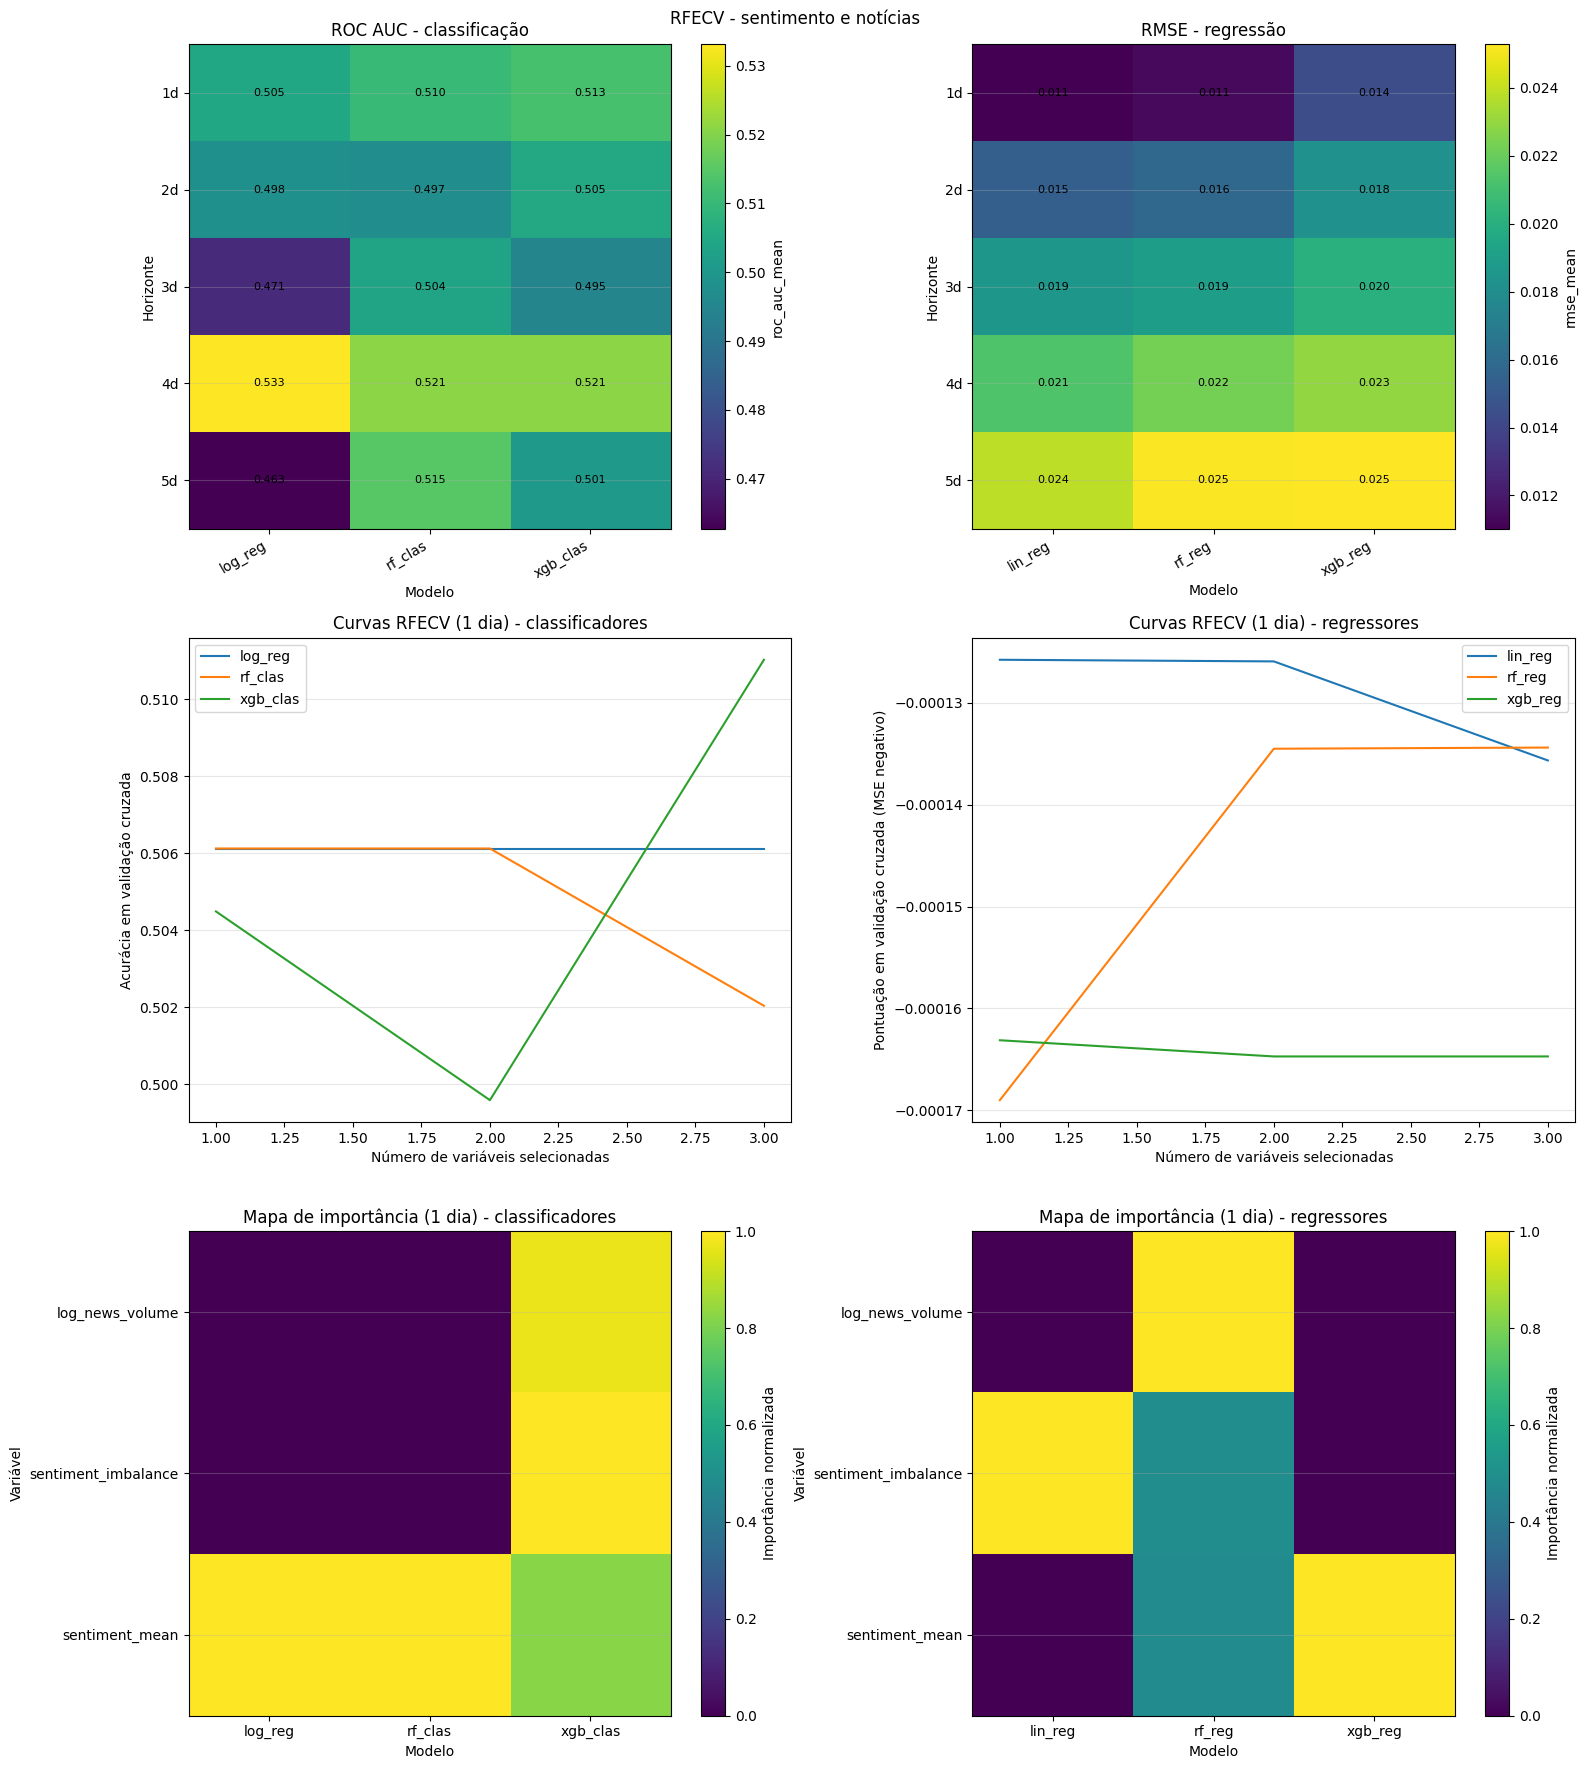

In [24]:
sentiment_rfecv_results = plot_rfecv_results(sentiment_features, "RFECV - sentimento e notícias", target_sets)


### RFECV com variáveis de preço


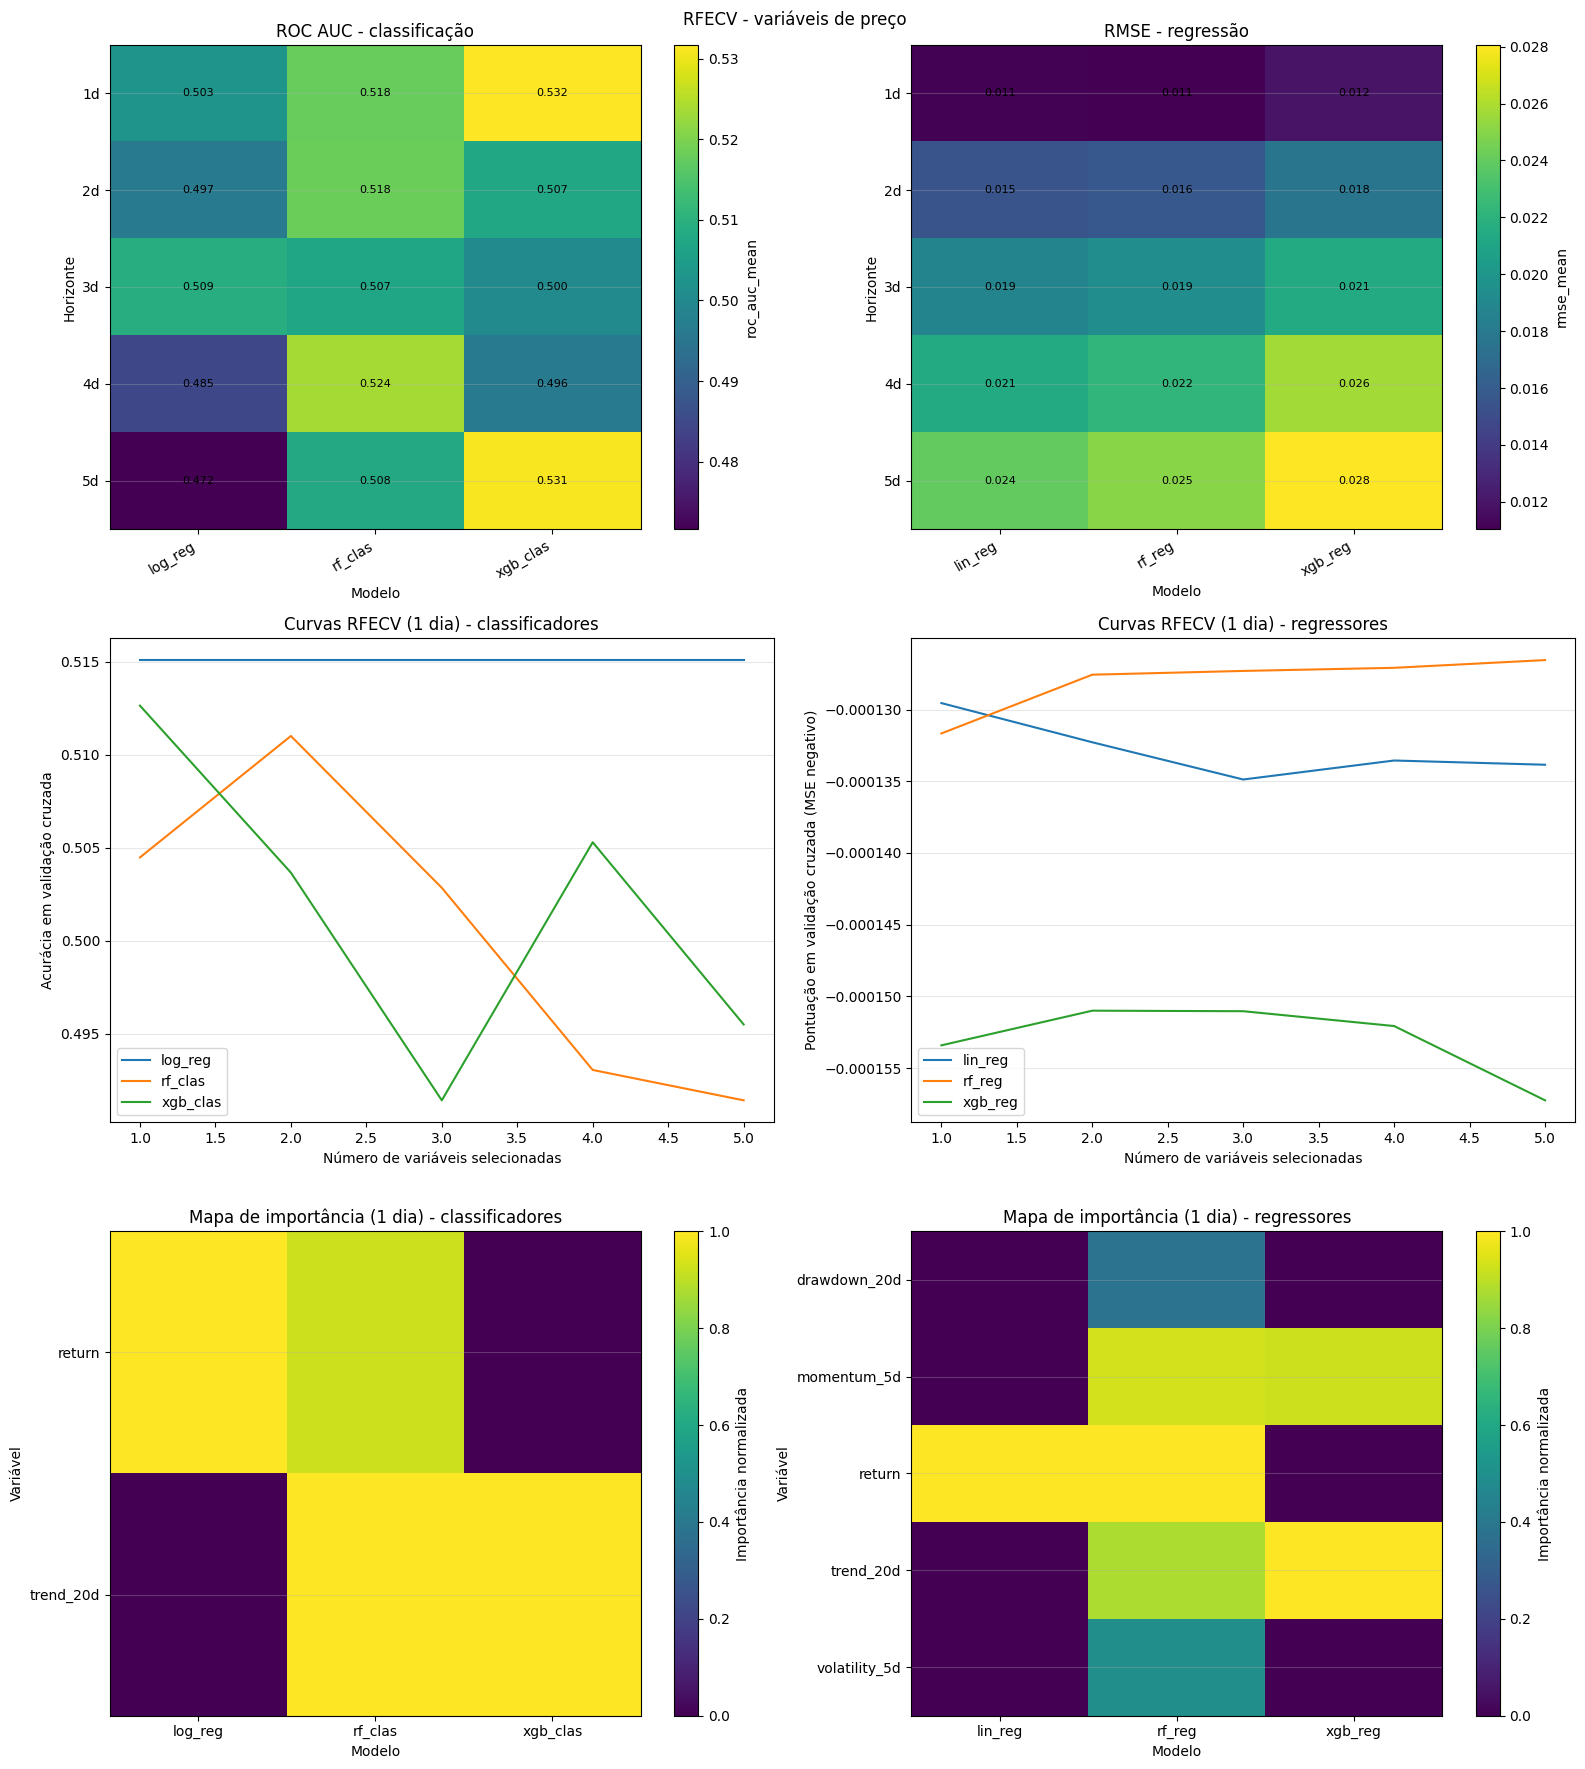

In [25]:
price_rfecv_results = plot_rfecv_results(price_features, "RFECV - variáveis de preço", target_sets)


### Teste com sentimento, tom e preço


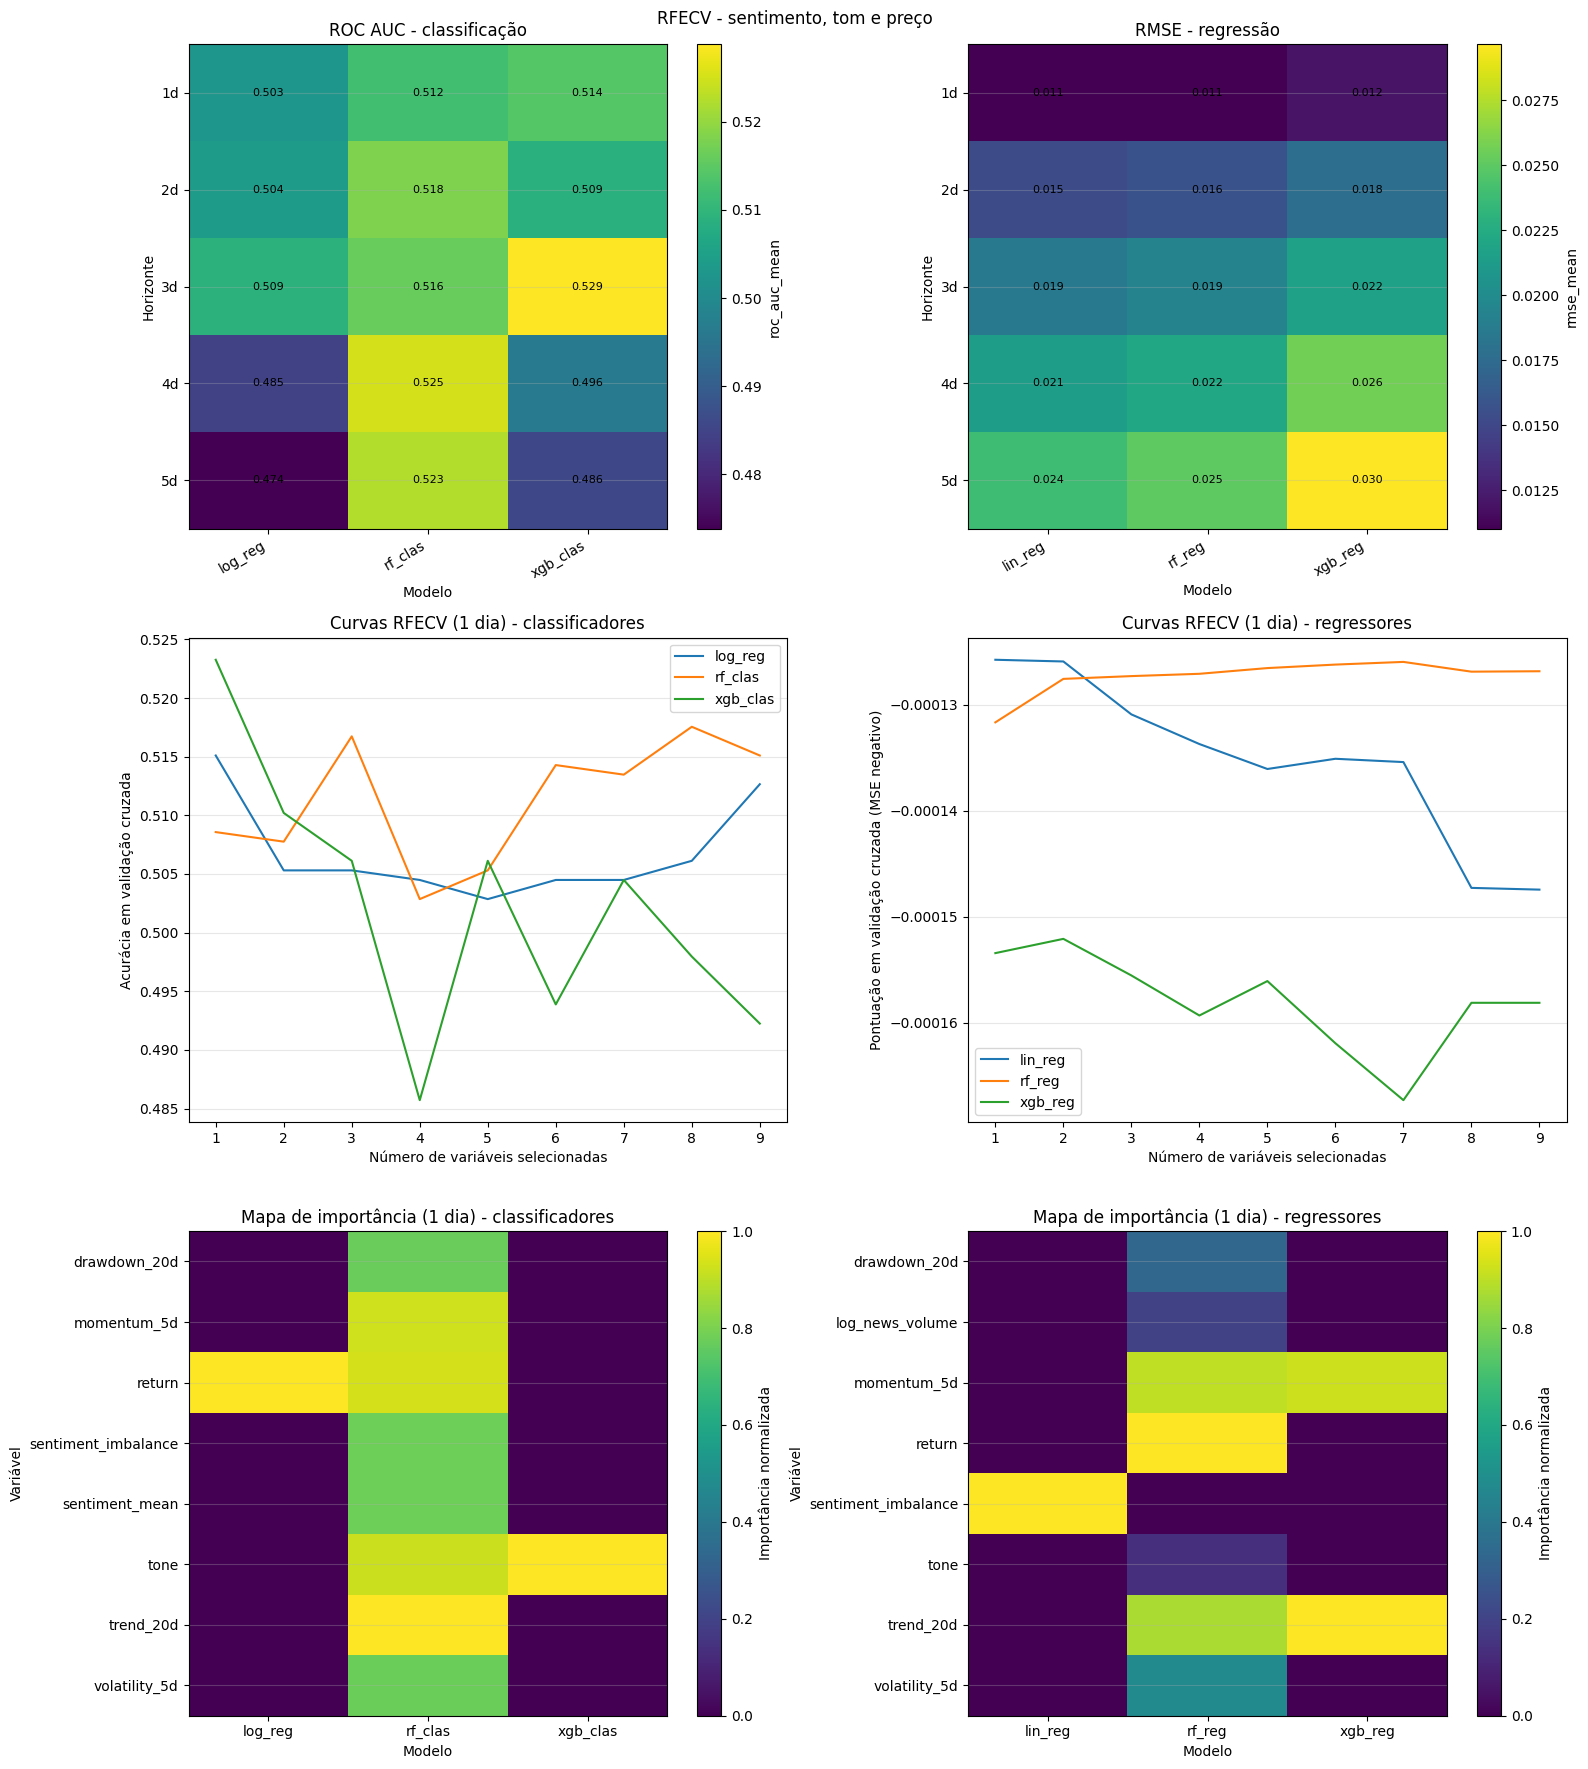

In [26]:
all_feature_rfecv_results = plot_rfecv_results(sentiment_features + price_features + gdelt_tone_features, "RFECV - sentimento, tom e preço", target_sets)


### Comparação dos testes com RFECV


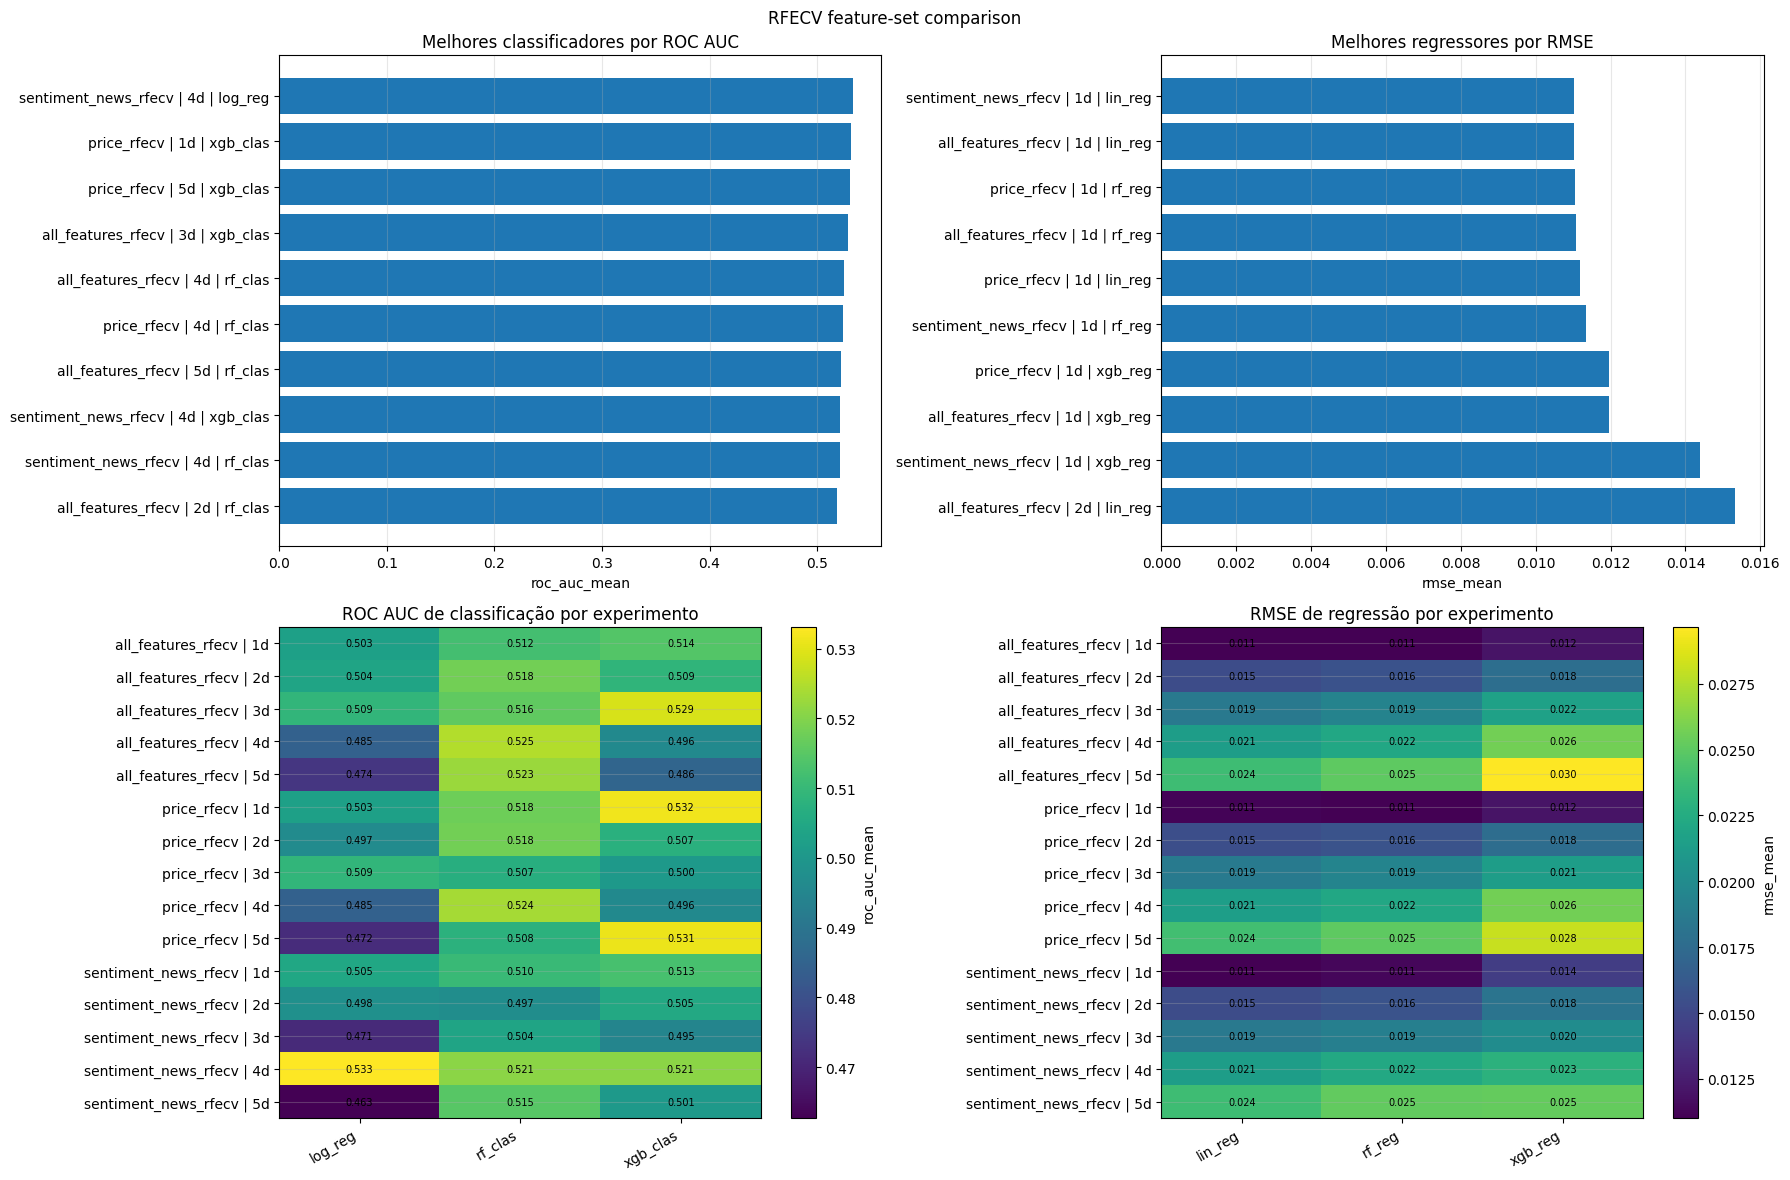

Ranking dos classificadores


,experiment,horizon,model,roc_auc_mean,accuracy_mean,f1_mean
0,sentiment_news_rfecv,4,log_reg,0.533130,0.511837,0.597052
1,price_rfecv,1,xgb_clas,0.531706,0.523265,0.544909
2,price_rfecv,5,xgb_clas,0.531006,0.530612,0.553065
3,all_features_rfecv,3,xgb_clas,0.528777,0.524082,0.544212
4,all_features_rfecv,4,rf_clas,0.525136,0.506939,0.534896
5,price_rfecv,4,rf_clas,0.523718,0.524082,0.562424
6,all_features_rfecv,5,rf_clas,0.522548,0.530612,0.540666
7,sentiment_news_rfecv,4,xgb_clas,0.520941,0.506939,0.505192
8,sentiment_news_rfecv,4,rf_clas,0.520909,0.511020,0.488253
9,all_features_rfecv,2,rf_clas,0.518143,0.525714,0.581718


Ranking dos regressores


,experiment,horizon,model,rmse_mean,mae_mean,r2_mean
0,sentiment_news_rfecv,1,lin_reg,0.011020,0.008535,-0.011723
1,all_features_rfecv,1,lin_reg,0.011020,0.008535,-0.011723
2,price_rfecv,1,rf_reg,0.011044,0.008535,-0.014900
3,all_features_rfecv,1,rf_reg,0.011062,0.008555,-0.019027
4,price_rfecv,1,lin_reg,0.011171,0.008757,-0.038412
5,sentiment_news_rfecv,1,rf_reg,0.011355,0.008738,-0.068459
6,price_rfecv,1,xgb_reg,0.011967,0.009279,-0.175685
7,all_features_rfecv,1,xgb_reg,0.011967,0.009279,-0.175685
8,sentiment_news_rfecv,1,xgb_reg,0.014396,0.010551,-0.752102
9,all_features_rfecv,2,lin_reg,0.015321,0.012273,-0.016290


In [27]:
rfecv_experiments = {
    "sentiment_news_rfecv": sentiment_rfecv_results,
    "price_rfecv": price_rfecv_results,
    "all_features_rfecv": all_feature_rfecv_results,
}

rfecv_comparison = plot_experiment_comparison(rfecv_experiments, "RFECV feature-set comparison")


### Ranking final de todos os experimentos


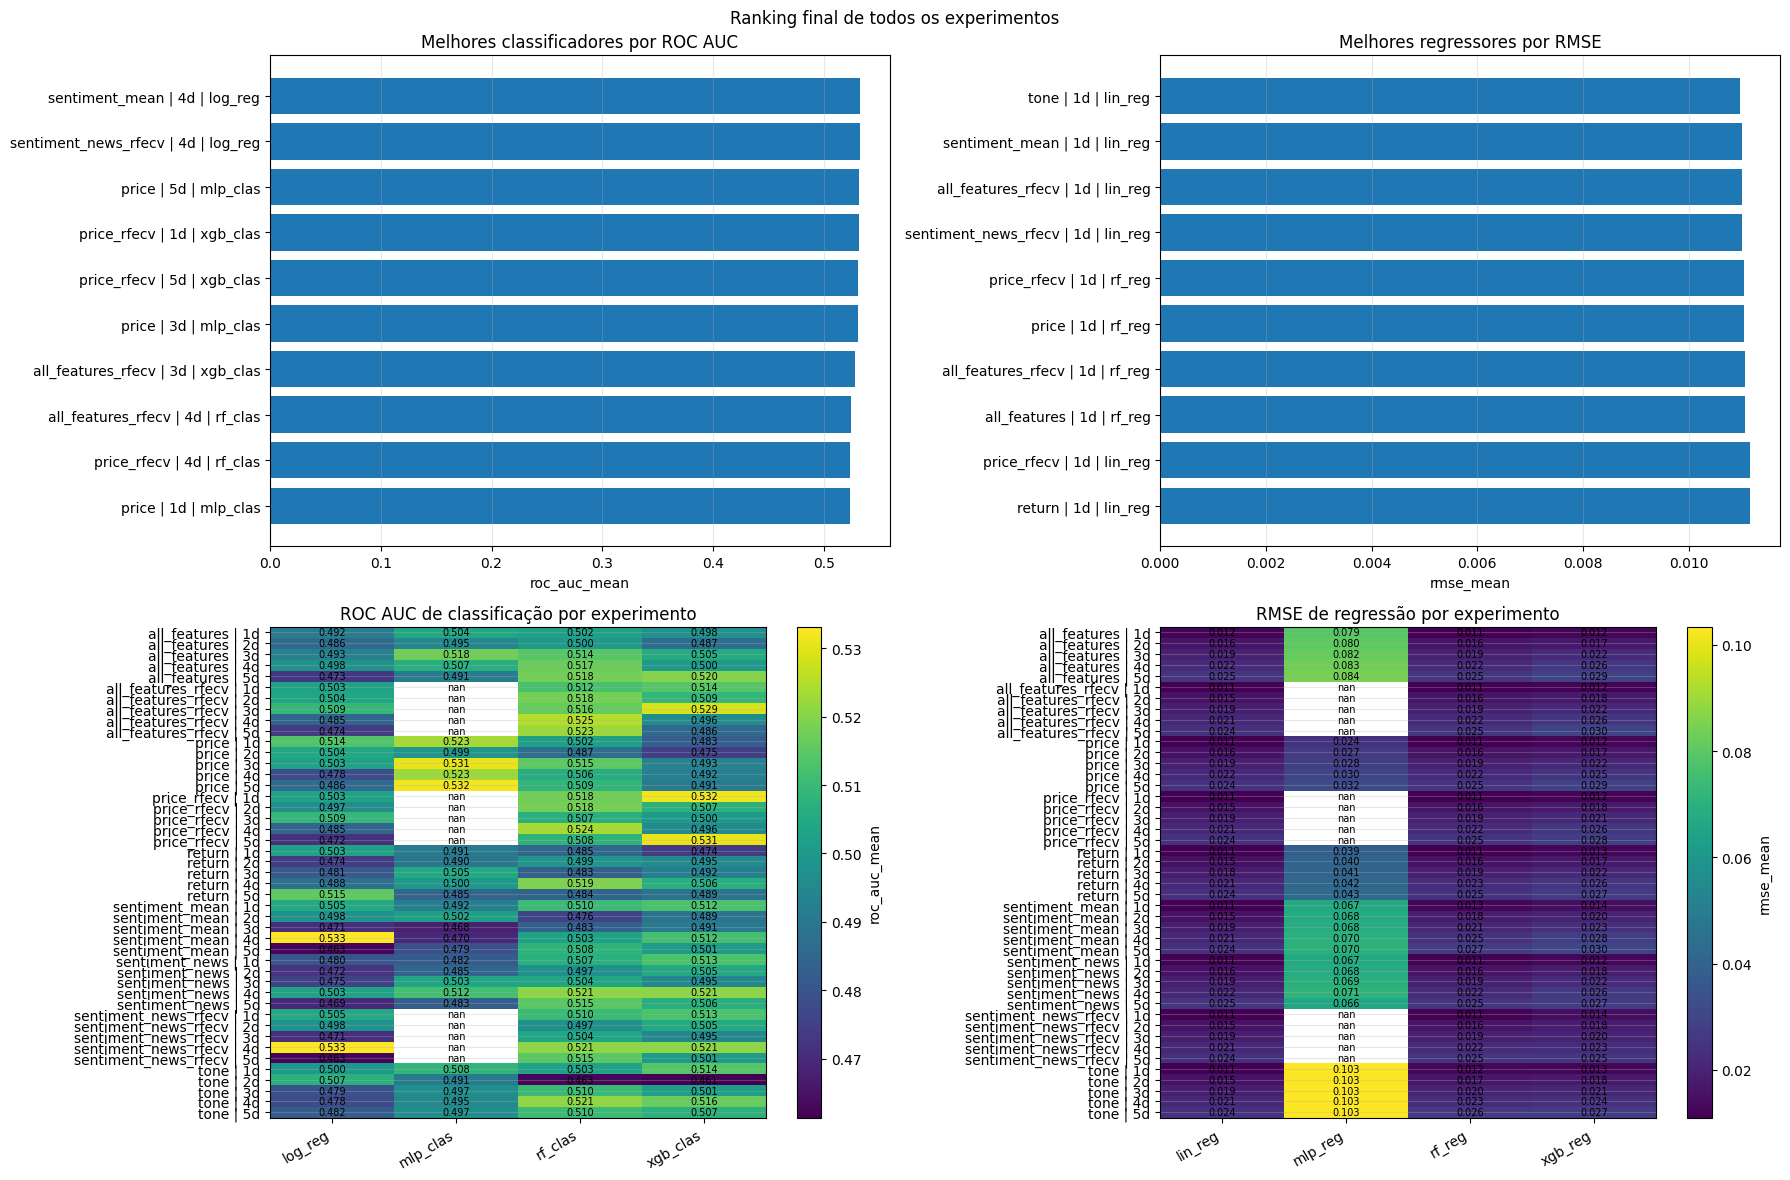

Ranking dos classificadores


,experiment,horizon,model,roc_auc_mean,accuracy_mean,f1_mean
0,sentiment_mean,4,log_reg,0.533130,0.511837,0.597052
1,sentiment_news_rfecv,4,log_reg,0.533130,0.511837,0.597052
2,price,5,mlp_clas,0.531864,0.498776,0.284479
3,price_rfecv,1,xgb_clas,0.531706,0.523265,0.544909
4,price_rfecv,5,xgb_clas,0.531006,0.530612,0.553065
...,...,...,...,...,...,...
160,sentiment_mean,3,mlp_clas,0.467847,0.505306,0.670081
161,sentiment_mean,5,log_reg,0.462709,0.490612,0.584203
162,sentiment_news_rfecv,5,log_reg,0.462709,0.490612,0.584203
163,tone,2,rf_clas,0.462573,0.463673,0.491949


Ranking dos regressores


,experiment,horizon,model,rmse_mean,mae_mean,r2_mean
0,tone,1,lin_reg,0.010977,0.008509,-0.005125
1,sentiment_mean,1,lin_reg,0.011020,0.008535,-0.011723
2,all_features_rfecv,1,lin_reg,0.011020,0.008535,-0.011723
3,sentiment_news_rfecv,1,lin_reg,0.011020,0.008535,-0.011723
4,price_rfecv,1,rf_reg,0.011044,0.008535,-0.014900
...,...,...,...,...,...,...
160,tone,2,mlp_reg,0.102909,0.085020,-46.711009
161,tone,3,mlp_reg,0.103028,0.084828,-31.724658
162,tone,4,mlp_reg,0.103086,0.084730,-23.656766
163,tone,5,mlp_reg,0.103223,0.084247,-18.839498


Melhor classificador: log_reg com sentiment_mean no horizonte de 4 dia(s) (ROC AUC = 0.533)
Melhor regressor: lin_reg com tone no horizonte de 1 dia(s) (RMSE = 0.01098)


In [28]:
all_experiments = {
    **standard_experiments,
    **rfecv_experiments,
}

final_comparison = plot_experiment_comparison(all_experiments, "Ranking final de todos os experimentos")
final_classifier_ranking, final_regressor_ranking = final_comparison[:2]

best_classifier = final_classifier_ranking.iloc[0]
best_regressor = final_regressor_ranking.iloc[0]

print(
    f"Melhor classificador: {best_classifier['model']} com {best_classifier['experiment']} "
    f"no horizonte de {best_classifier['horizon']} dia(s) "
    f"(ROC AUC = {best_classifier['roc_auc_mean']:.3f})"
)
print(
    f"Melhor regressor: {best_regressor['model']} com {best_regressor['experiment']} "
    f"no horizonte de {best_regressor['horizon']} dia(s) "
    f"(RMSE = {best_regressor['rmse_mean']:.5f})"
)


### Gráficos finais para a seção de resultados


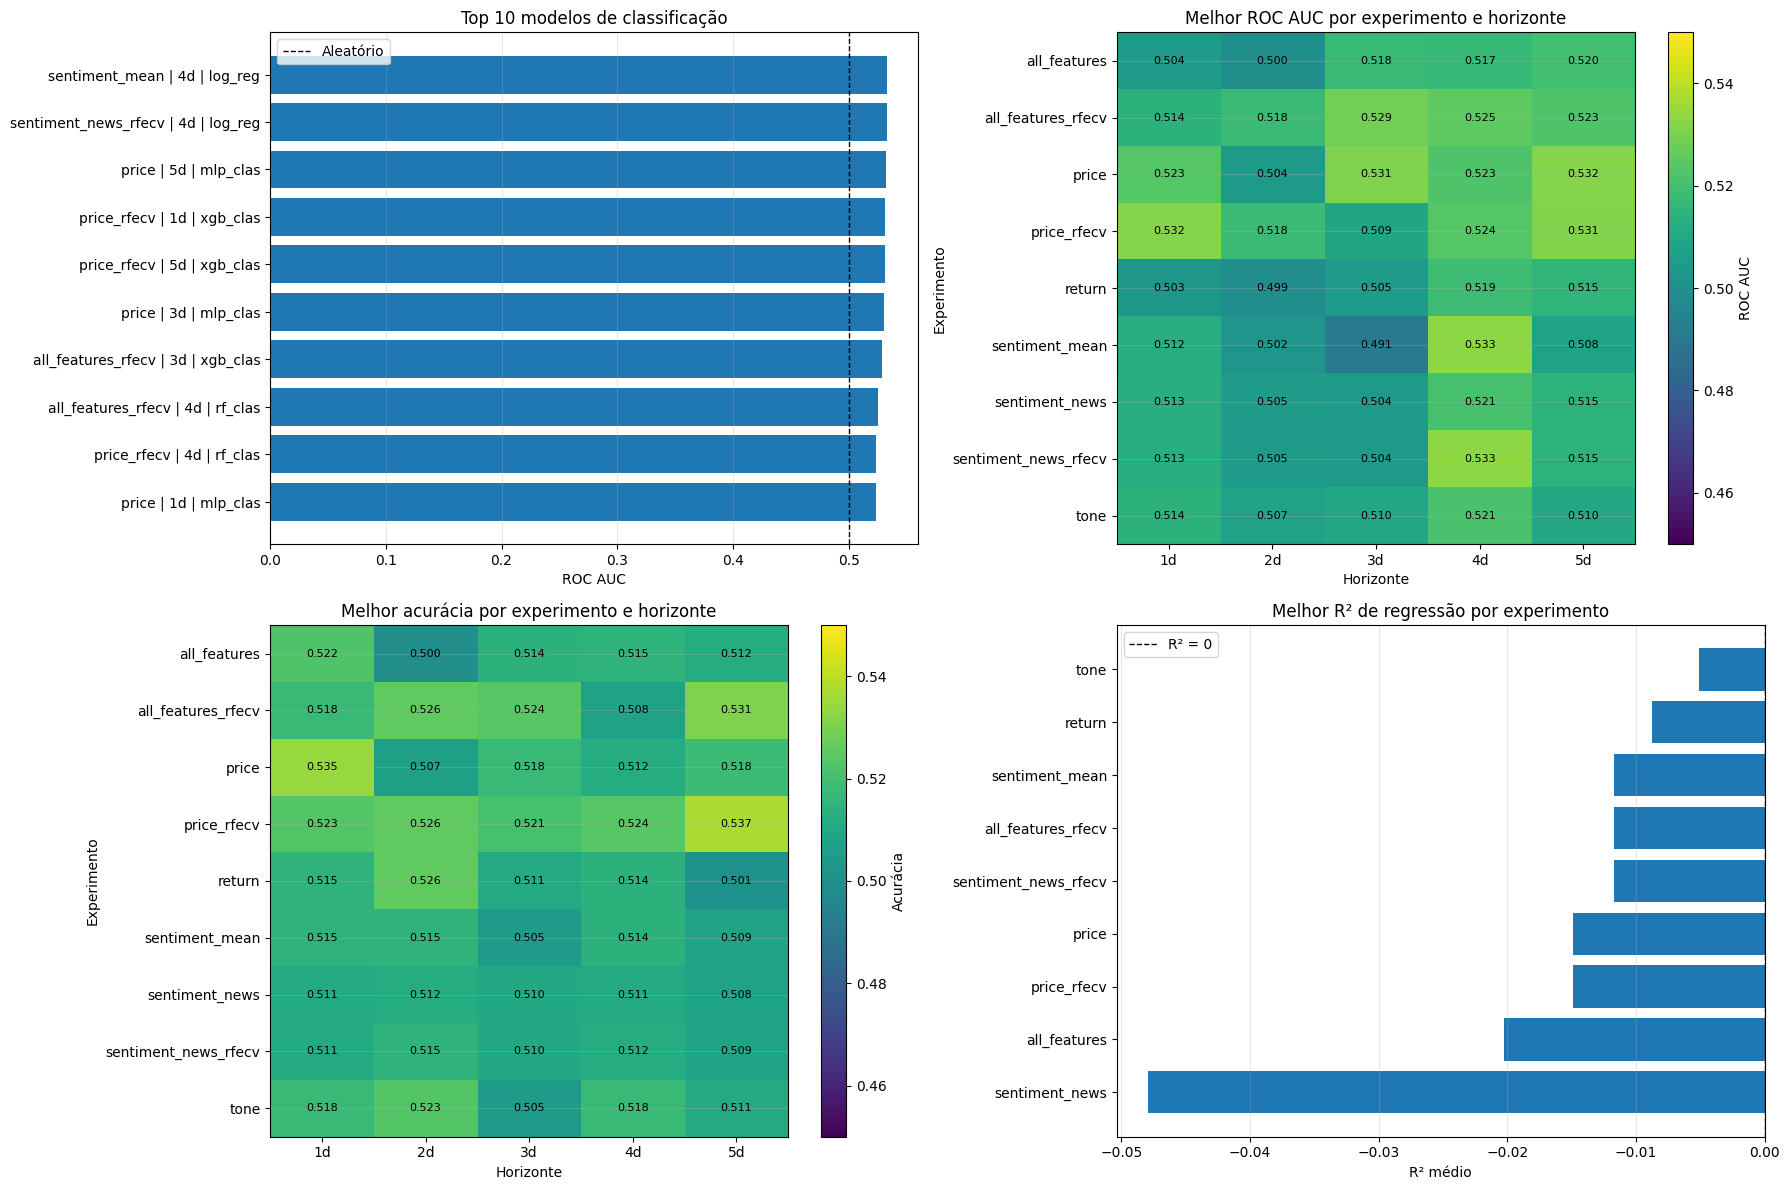

In [29]:
clf_results = final_comparison[2].copy()
reg_results = final_comparison[3].copy()

best_by_experiment = (
    clf_results
    .sort_values("roc_auc_mean", ascending=False)
    .groupby(["experiment", "horizon"], as_index=False)
    .first()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top 10 classificadores
ranking_plot = final_classifier_ranking.head(10).copy()
ranking_plot["label"] = ranking_plot["experiment"] + " | " + ranking_plot["horizon"].astype(str) + "d | " + ranking_plot["model"]
axes[0, 0].barh(np.arange(len(ranking_plot)), ranking_plot["roc_auc_mean"])
axes[0, 0].set_yticks(np.arange(len(ranking_plot)), ranking_plot["label"])
axes[0, 0].invert_yaxis()
axes[0, 0].axvline(0.5, color="black", linestyle="--", linewidth=1, label="Aleatório")
axes[0, 0].legend()
style_axis(axes[0, 0], "Top 10 modelos de classificação", "ROC AUC", grid_axis="x")

# Melhor ROC AUC por experimento e horizonte
heat = best_by_experiment.pivot_table(index="experiment", columns="horizon", values="roc_auc_mean")
image = axes[0, 1].imshow(heat.values, aspect="auto", vmin=0.45, vmax=max(0.55, heat.max().max()))
axes[0, 1].set_xticks(range(len(heat.columns)), [f"{h}d" for h in heat.columns])
axes[0, 1].set_yticks(range(len(heat.index)), heat.index)
for row in range(heat.shape[0]):
    for col in range(heat.shape[1]):
        axes[0, 1].text(col, row, f"{heat.iloc[row, col]:.3f}", ha="center", va="center", fontsize=8)
plt.colorbar(image, ax=axes[0, 1], label="ROC AUC")
style_axis(axes[0, 1], "Melhor ROC AUC por experimento e horizonte", "Horizonte", "Experimento")

# Melhor acurácia por experimento e horizonte
acc = (
    clf_results
    .sort_values("accuracy_mean", ascending=False)
    .groupby(["experiment", "horizon"], as_index=False)
    .first()
    .pivot_table(index="experiment", columns="horizon", values="accuracy_mean")
)
image = axes[1, 0].imshow(acc.values, aspect="auto", vmin=0.45, vmax=max(0.55, acc.max().max()))
axes[1, 0].set_xticks(range(len(acc.columns)), [f"{h}d" for h in acc.columns])
axes[1, 0].set_yticks(range(len(acc.index)), acc.index)
for row in range(acc.shape[0]):
    for col in range(acc.shape[1]):
        axes[1, 0].text(col, row, f"{acc.iloc[row, col]:.3f}", ha="center", va="center", fontsize=8)
plt.colorbar(image, ax=axes[1, 0], label="Acurácia")
style_axis(axes[1, 0], "Melhor acurácia por experimento e horizonte", "Horizonte", "Experimento")

# Regressão como evidência negativa
best_reg_by_exp = (
    reg_results
    .sort_values("r2_mean", ascending=False)
    .groupby("experiment", as_index=False)
    .first()
    .sort_values("r2_mean", ascending=False)
)
axes[1, 1].barh(best_reg_by_exp["experiment"], best_reg_by_exp["r2_mean"])
axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1, label="R² = 0")
axes[1, 1].invert_yaxis()
axes[1, 1].legend()
style_axis(axes[1, 1], "Melhor R² de regressão por experimento", "R² médio", grid_axis="x")

plt.tight_layout()
plt.show()


## Tabelas consolidadas para o TCC


In [30]:
# Consolidação dos resultados para uso na seção de resultados do TCC.
# Esta célula deve ser executada depois do ranking final.

clf_results = final_comparison[2].copy()
reg_results = final_comparison[3].copy()

experiment_names = {
    "return": "Apenas retorno",
    "sentiment_mean": "Apenas sentimento médio",
    "tone": "Apenas tom GDELT",
    "sentiment_news": "Sentimento e notícias",
    "price": "Variáveis de preço",
    "all_features": "Sentimento, tom e preço",
    "sentiment_news_rfecv": "RFECV - sentimento e notícias",
    "price_rfecv": "RFECV - variáveis de preço",
    "all_features_rfecv": "RFECV - sentimento, tom e preço",
}

model_names = {
    "log_reg": "Regressão logística",
    "rf_clas": "Random forest",
    "xgb_clas": "XGBoost",
    "mlp_clas": "MLP",
    "lin_reg": "Regressão linear",
    "rf_reg": "Random forest",
    "xgb_reg": "XGBoost",
    "mlp_reg": "MLP",
}

def format_result_table(df):
    out = df.copy()
    out["experimento"] = out["experiment"].map(experiment_names).fillna(out["experiment"])
    out["modelo"] = out["model"].map(model_names).fillna(out["model"])
    out["horizonte"] = out["horizon"].astype(str) + " dia(s)"
    return out

best_clf_by_horizon = (
    clf_results
    .sort_values("roc_auc_mean", ascending=False)
    .groupby("horizon", as_index=False)
    .first()
)

best_reg_by_horizon = (
    reg_results
    .sort_values("rmse_mean", ascending=True)
    .groupby("horizon", as_index=False)
    .first()
)

tabela_melhores_por_horizonte = pd.concat([
    format_result_table(best_clf_by_horizon).assign(tipo_problema="Classificação da direção")[[
        "tipo_problema", "horizonte", "experimento", "modelo", "roc_auc_mean", "accuracy_mean", "f1_mean"
    ]].rename(columns={
        "roc_auc_mean": "ROC AUC médio",
        "accuracy_mean": "Acurácia média",
        "f1_mean": "F1 médio",
    }),
    format_result_table(best_reg_by_horizon).assign(tipo_problema="Regressão do retorno")[[
        "tipo_problema", "horizonte", "experimento", "modelo", "rmse_mean", "mae_mean", "r2_mean"
    ]].rename(columns={
        "rmse_mean": "RMSE médio",
        "mae_mean": "MAE médio",
        "r2_mean": "R² médio",
    }),
], ignore_index=True)

print("Tabela 1 - Melhores resultados por horizonte e tipo de problema")
display(tabela_melhores_por_horizonte)


Tabela 1 - Melhores resultados por horizonte e tipo de problema


,tipo_problema,horizonte,experimento,modelo,ROC AUC médio,Acurácia média,F1 médio,RMSE médio,MAE médio,R² médio
0,Classificação da direção,1 dia(s),RFECV - variáveis de preço,XGBoost,0.531706,0.523265,0.544909,NaN,NaN,NaN
1,Classificação da direção,2 dia(s),RFECV - variáveis de preço,Random forest,0.518143,0.525714,0.581718,NaN,NaN,NaN
2,Classificação da direção,3 dia(s),Variáveis de preço,MLP,0.530818,0.505306,0.405885,NaN,NaN,NaN
3,Classificação da direção,4 dia(s),Apenas sentimento médio,Regressão logística,0.533130,0.511837,0.597052,NaN,NaN,NaN
4,Classificação da direção,5 dia(s),Variáveis de preço,MLP,0.531864,0.498776,0.284479,NaN,NaN,NaN
5,Regressão do retorno,1 dia(s),Apenas tom GDELT,Regressão linear,NaN,NaN,NaN,0.010977,0.008509,-0.005125
6,Regressão do retorno,2 dia(s),Apenas retorno,Regressão linear,NaN,NaN,NaN,0.015261,0.012213,-0.008772
7,Regressão do retorno,3 dia(s),Apenas retorno,Regressão linear,NaN,NaN,NaN,0.018444,0.014722,-0.015087
8,Regressão do retorno,4 dia(s),Apenas retorno,Regressão linear,NaN,NaN,NaN,0.021215,0.016914,-0.022092
9,Regressão do retorno,5 dia(s),Apenas retorno,Regressão linear,NaN,NaN,NaN,0.023762,0.019022,-0.026982


### Rankings e sínteses adicionais


In [31]:
tabela_top_classificacao = (
    format_result_table(final_classifier_ranking)
    .loc[:, ["horizonte", "experimento", "modelo", "roc_auc_mean", "accuracy_mean", "f1_mean"]]
    .rename(columns={
        "roc_auc_mean": "ROC AUC médio",
        "accuracy_mean": "Acurácia média",
        "f1_mean": "F1 médio",
    })
    .head(15)
)

best_clf_by_experiment = (
    clf_results
    .sort_values("roc_auc_mean", ascending=False)
    .groupby("experiment", as_index=False)
    .first()
)

tabela_melhor_por_experimento = (
    format_result_table(best_clf_by_experiment)
    .loc[:, ["experimento", "horizonte", "modelo", "roc_auc_mean", "accuracy_mean", "f1_mean"]]
    .rename(columns={
        "roc_auc_mean": "Melhor ROC AUC médio",
        "accuracy_mean": "Acurácia média",
        "f1_mean": "F1 médio",
    })
    .sort_values("Melhor ROC AUC médio", ascending=False)
)

best_reg_by_experiment = (
    reg_results
    .sort_values("r2_mean", ascending=False)
    .groupby("experiment", as_index=False)
    .first()
)

tabela_regressao_por_experimento = (
    format_result_table(best_reg_by_experiment)
    .loc[:, ["experimento", "horizonte", "modelo", "rmse_mean", "mae_mean", "r2_mean"]]
    .rename(columns={
        "rmse_mean": "RMSE médio",
        "mae_mean": "MAE médio",
        "r2_mean": "Melhor R² médio",
    })
    .sort_values("Melhor R² médio", ascending=False)
)

print("Tabela 2 - Top 15 modelos de classificação")
display(tabela_top_classificacao)

print("Tabela 3 - Melhor classificador por grupo de variáveis")
display(tabela_melhor_por_experimento)

print("Tabela 4 - Melhor regressor por grupo de variáveis")
display(tabela_regressao_por_experimento)


Tabela 2 - Top 15 modelos de classificação


,horizonte,experimento,modelo,ROC AUC médio,Acurácia média,F1 médio
0,4 dia(s),Apenas sentimento médio,Regressão logística,0.533130,0.511837,0.597052
1,4 dia(s),RFECV - sentimento e notícias,Regressão logística,0.533130,0.511837,0.597052
2,5 dia(s),Variáveis de preço,MLP,0.531864,0.498776,0.284479
3,1 dia(s),RFECV - variáveis de preço,XGBoost,0.531706,0.523265,0.544909
4,5 dia(s),RFECV - variáveis de preço,XGBoost,0.531006,0.530612,0.553065
5,3 dia(s),Variáveis de preço,MLP,0.530818,0.505306,0.405885
6,3 dia(s),"RFECV - sentimento, tom e preço",XGBoost,0.528777,0.524082,0.544212
7,4 dia(s),"RFECV - sentimento, tom e preço",Random forest,0.525136,0.506939,0.534896
8,4 dia(s),RFECV - variáveis de preço,Random forest,0.523718,0.524082,0.562424
9,1 dia(s),Variáveis de preço,MLP,0.523474,0.534694,0.534505


Tabela 3 - Melhor classificador por grupo de variáveis


,experimento,horizonte,modelo,Melhor ROC AUC médio,Acurácia média,F1 médio
5,Apenas sentimento médio,4 dia(s),Regressão logística,0.533130,0.511837,0.597052
7,RFECV - sentimento e notícias,4 dia(s),Regressão logística,0.533130,0.511837,0.597052
2,Variáveis de preço,5 dia(s),MLP,0.531864,0.498776,0.284479
3,RFECV - variáveis de preço,1 dia(s),XGBoost,0.531706,0.523265,0.544909
1,"RFECV - sentimento, tom e preço",3 dia(s),XGBoost,0.528777,0.524082,0.544212
8,Apenas tom GDELT,4 dia(s),Random forest,0.521168,0.516735,0.508650
6,Sentimento e notícias,4 dia(s),XGBoost,0.520941,0.506939,0.505192
0,"Sentimento, tom e preço",5 dia(s),XGBoost,0.519730,0.508571,0.461407
4,Apenas retorno,4 dia(s),Random forest,0.519125,0.512653,0.563647


Tabela 4 - Melhor regressor por grupo de variáveis


,experimento,horizonte,modelo,RMSE médio,MAE médio,Melhor R² médio
8,Apenas tom GDELT,1 dia(s),Regressão linear,0.010977,0.008509,-0.005125
4,Apenas retorno,2 dia(s),Regressão linear,0.015261,0.012213,-0.008772
5,Apenas sentimento médio,1 dia(s),Regressão linear,0.011020,0.008535,-0.011723
1,"RFECV - sentimento, tom e preço",1 dia(s),Regressão linear,0.011020,0.008535,-0.011723
7,RFECV - sentimento e notícias,1 dia(s),Regressão linear,0.011020,0.008535,-0.011723
2,Variáveis de preço,1 dia(s),Random forest,0.011044,0.008535,-0.014900
3,RFECV - variáveis de preço,1 dia(s),Random forest,0.011044,0.008535,-0.014900
0,"Sentimento, tom e preço",1 dia(s),Random forest,0.011066,0.008542,-0.020231
6,Sentimento e notícias,2 dia(s),Regressão linear,0.015572,0.012479,-0.047943


### Gráficos consolidados para o texto dos resultados


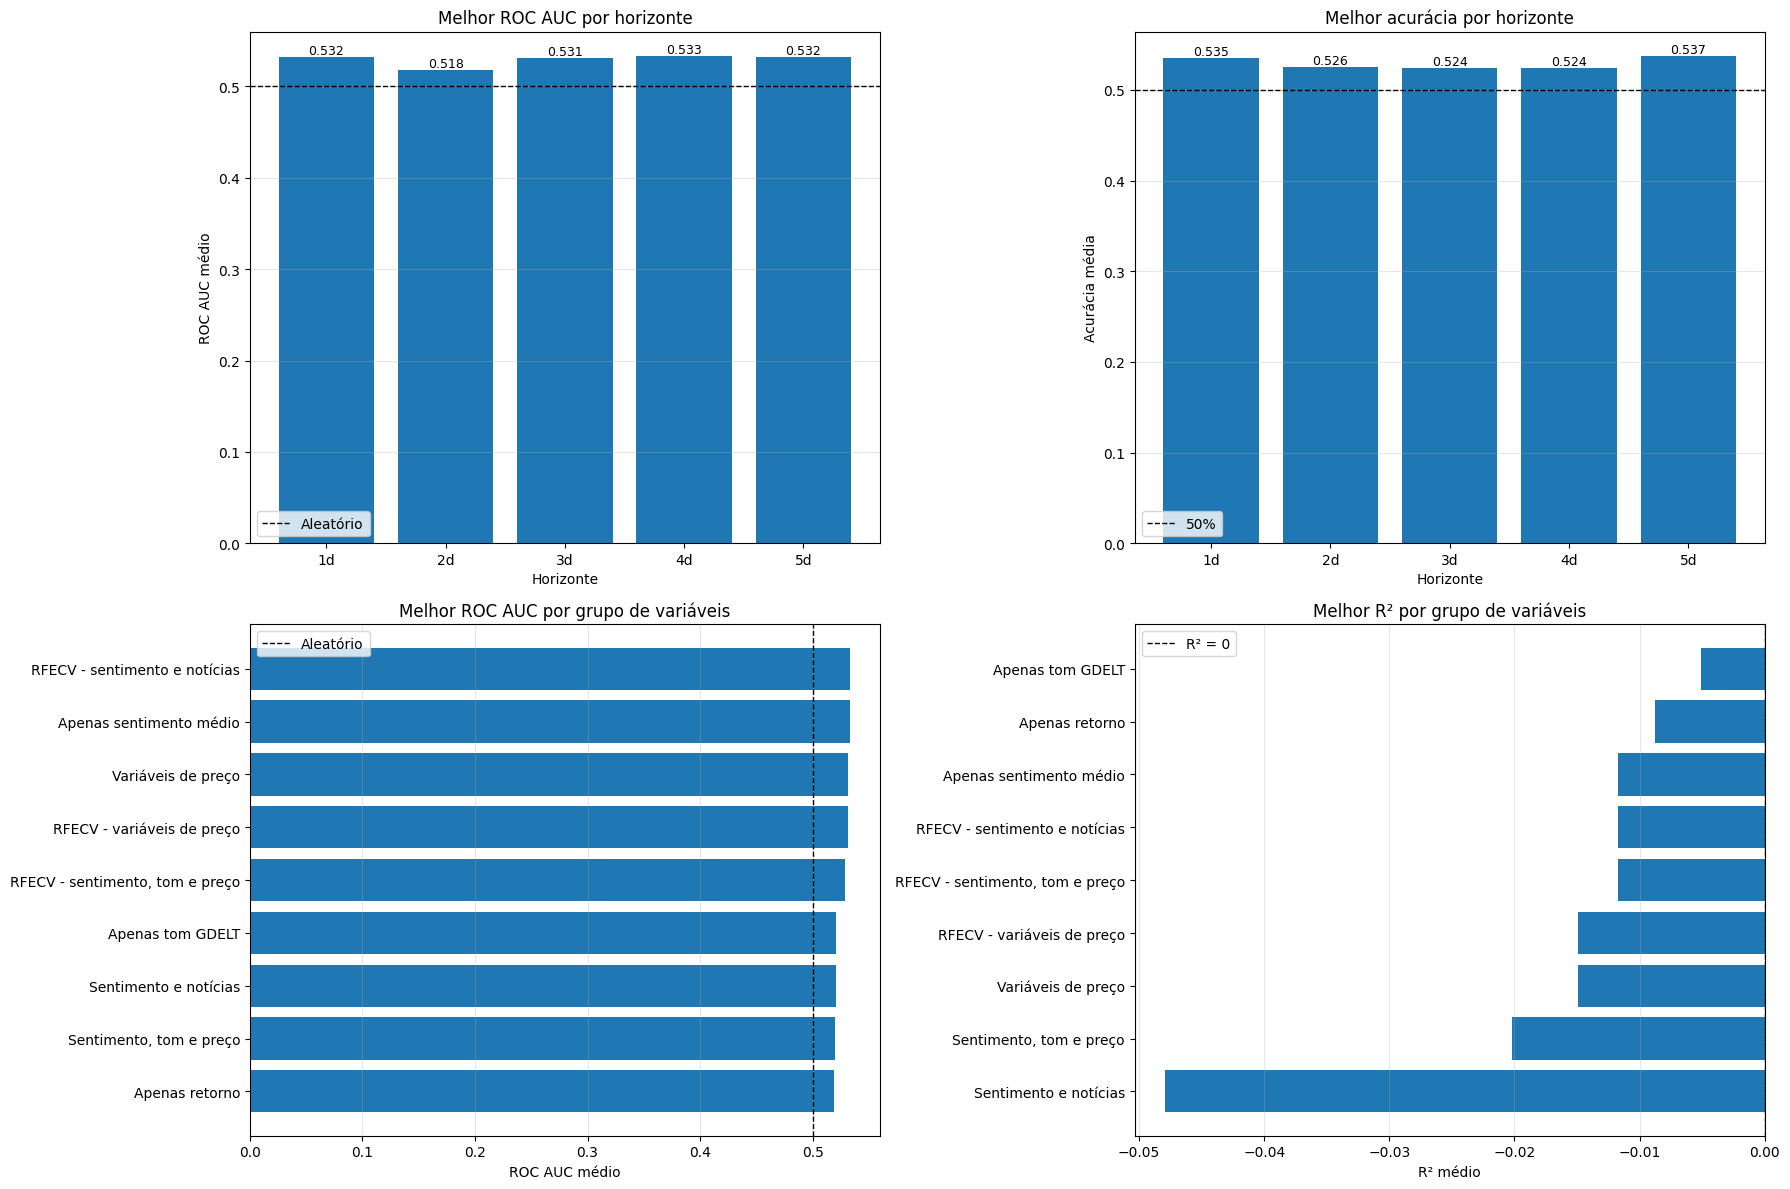

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Melhor ROC AUC por horizonte
best_clf_plot = best_clf_by_horizon.sort_values("horizon")
axes[0, 0].bar(best_clf_plot["horizon"].astype(str) + "d", best_clf_plot["roc_auc_mean"])
axes[0, 0].axhline(0.5, color="black", linestyle="--", linewidth=1, label="Aleatório")
for _, row in best_clf_plot.iterrows():
    axes[0, 0].text(
        str(row["horizon"]) + "d",
        row["roc_auc_mean"],
        f"{row['roc_auc_mean']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[0, 0].legend()
style_axis(axes[0, 0], "Melhor ROC AUC por horizonte", "Horizonte", "ROC AUC médio")

# Melhor acurácia por horizonte
best_acc_by_horizon = (
    clf_results
    .sort_values("accuracy_mean", ascending=False)
    .groupby("horizon", as_index=False)
    .first()
    .sort_values("horizon")
)
axes[0, 1].bar(best_acc_by_horizon["horizon"].astype(str) + "d", best_acc_by_horizon["accuracy_mean"])
axes[0, 1].axhline(0.5, color="black", linestyle="--", linewidth=1, label="50%")
for _, row in best_acc_by_horizon.iterrows():
    axes[0, 1].text(
        str(row["horizon"]) + "d",
        row["accuracy_mean"],
        f"{row['accuracy_mean']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[0, 1].legend()
style_axis(axes[0, 1], "Melhor acurácia por horizonte", "Horizonte", "Acurácia média")

# Melhor classificador por experimento
exp_plot = tabela_melhor_por_experimento.sort_values("Melhor ROC AUC médio")
axes[1, 0].barh(exp_plot["experimento"], exp_plot["Melhor ROC AUC médio"])
axes[1, 0].axvline(0.5, color="black", linestyle="--", linewidth=1, label="Aleatório")
axes[1, 0].legend()
style_axis(axes[1, 0], "Melhor ROC AUC por grupo de variáveis", "ROC AUC médio", grid_axis="x")

# Regressão: melhor R² por experimento
reg_plot = tabela_regressao_por_experimento.sort_values("Melhor R² médio")
axes[1, 1].barh(reg_plot["experimento"], reg_plot["Melhor R² médio"])
axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1, label="R² = 0")
axes[1, 1].legend()
style_axis(axes[1, 1], "Melhor R² por grupo de variáveis", "R² médio", grid_axis="x")

plt.tight_layout()
plt.show()


### Síntese quantitativa para discussão


In [33]:
n_classificadores_acima_50 = (clf_results["accuracy_mean"] > 0.50).sum()
n_classificadores_acima_52 = (clf_results["accuracy_mean"] > 0.52).sum()
n_classificadores_auc_acima_50 = (clf_results["roc_auc_mean"] > 0.50).sum()
n_classificadores_auc_acima_53 = (clf_results["roc_auc_mean"] > 0.53).sum()
melhor_auc = final_classifier_ranking.iloc[0]
melhor_acc = clf_results.sort_values("accuracy_mean", ascending=False).iloc[0]
melhor_r2 = reg_results.sort_values("r2_mean", ascending=False).iloc[0]

resumo_resultados_tcc = pd.DataFrame([
    ["Modelos de classificação com acurácia média > 50%", n_classificadores_acima_50],
    ["Modelos de classificação com acurácia média > 52%", n_classificadores_acima_52],
    ["Modelos de classificação com ROC AUC médio > 0,50", n_classificadores_auc_acima_50],
    ["Modelos de classificação com ROC AUC médio > 0,53", n_classificadores_auc_acima_53],
    ["Melhor ROC AUC médio", f"{melhor_auc['roc_auc_mean']:.3f} ({experiment_names.get(melhor_auc['experiment'], melhor_auc['experiment'])}, {melhor_auc['horizon']}d, {model_names.get(melhor_auc['model'], melhor_auc['model'])})"],
    ["Melhor acurácia média", f"{melhor_acc['accuracy_mean']:.3f} ({experiment_names.get(melhor_acc['experiment'], melhor_acc['experiment'])}, {melhor_acc['horizon']}d, {model_names.get(melhor_acc['model'], melhor_acc['model'])})"],
    ["Melhor R² médio na regressão", f"{melhor_r2['r2_mean']:.3f} ({experiment_names.get(melhor_r2['experiment'], melhor_r2['experiment'])}, {melhor_r2['horizon']}d, {model_names.get(melhor_r2['model'], melhor_r2['model'])})"],
], columns=["Indicador", "Resultado"])

print("Tabela 5 - Síntese quantitativa dos resultados")
display(resumo_resultados_tcc)


Tabela 5 - Síntese quantitativa dos resultados


,Indicador,Resultado
0,Modelos de classificação com acurácia média > 50%,106
1,Modelos de classificação com acurácia média > 52%,15
2,"Modelos de classificação com ROC AUC médio > 0,50",88
3,"Modelos de classificação com ROC AUC médio > 0,53",6
4,Melhor ROC AUC médio,"0.533 (Apenas sentimento médio, 4d, Regressão ..."
5,Melhor acurácia média,"0.537 (RFECV - variáveis de preço, 5d, Random ..."
6,Melhor R² médio na regressão,"-0.005 (Apenas tom GDELT, 1d, Regressão linear)"
